# Análise de Emoções nos Hinos da ICM
Este notebook utiliza modelos de NLP para identificar emoções predominantes nos textos dos hinos da coletânea principal da Igreja Cristã Maranata.

O objetivo é classificar os hinos quanto às emoções transmitidas, visualizar a distribuição das emoções e salvar os resultados para futuras análises.

---
**Conteúdo do notebook:**
- Carregamento do modelo de emoções (BERT-pt-emotion)
- Processamento dos textos dos hinos para análise de emoções
- Visualização da distribuição das emoções dominantes
- Estatísticas e exemplos por emoção
- Visualização detalhada (heatmap)
- Extração das 3 emoções mais fortes por hino
- Salvamento dos resultados enriquecidos

Este material é público e pode ser compartilhado para fins de pesquisa, estudo ou divulgação cultural.

---

**A seguir:** Carregamento do modelo de emoções e dos dados dos hinos, definição das funções para processamento dos textos e classificação das emoções.

In [1]:
from transformers import pipeline
import pandas as pd
import torch

hinos_analise: pd.DataFrame = pd.read_pickle(
    "..\\assets\\hinos_analise_embeddings_complete.pkl"
)

# Carregar modelo multilíngue de emoções
model_name = "pysentimiento/bert-pt-emotion"
classifier = pipeline(
    "text-classification",
    model=model_name,
    tokenizer=model_name,
    top_k=None,  # Substitui return_all_scores=True (depreciado)
    max_length=512,  # Limite máximo de tokens do BERT
    truncation=True,  # Trunca textos longos automaticamente
    device=-1,  # Força uso da CPU para evitar problemas de memória
)


# Função para juntar e truncar tokens já tratados
def texto_truncado_tokens(tokens, max_tokens=400):
    if not isinstance(tokens, list):
        return ""
    # Trunca a lista de tokens e junta em uma string
    return " ".join(tokens[:max_tokens])


# Classificar emoções usando a coluna token_no_stops
def analisar_emocoes_tokens(tokens):
    try:
        texto = texto_truncado_tokens(tokens)
        if not texto.strip():
            return {}
        resultado = classifier(texto)
        if isinstance(resultado, list) and len(resultado) > 0:
            emocoes_lista = resultado[0]
            if isinstance(emocoes_lista, list):
                return {r["label"]: r["score"] for r in emocoes_lista}
        return {}
    except Exception as e:
        print(f"Erro ao processar texto: {str(e)[:100]}...")
        return {}

Device set to use cpu


---

**A seguir:** Processamento dos hinos em lotes para análise de emoções, salvando os resultados e exibindo amostras dos dados processados.

In [2]:
import time

# Processar todos os hinos (pode demorar alguns minutos)
start_time = time.time()

# Processar em lotes para mostrar progresso
batch_size = 50
total_batches = len(hinos_analise) // batch_size + 1

all_emotions = []
for i in range(0, len(hinos_analise), batch_size):
    batch = hinos_analise.iloc[i : i + batch_size]
    batch_emotions = batch["tokens_no_stops"].apply(analisar_emocoes_tokens)
    all_emotions.extend(batch_emotions.tolist())

    current_batch = i // batch_size + 1
    print(
        f"Lote {current_batch}/{total_batches} concluído ({i+len(batch)}/{len(hinos_analise)} hinos)"
    )

# Adicionar resultados ao dataframe
hinos_analise["emocoes"] = all_emotions

end_time = time.time()
print(f"\nProcessamento concluído em {end_time - start_time:.1f} segundos!")
print(f"Total de hinos processados: {len(hinos_analise)}")

# Mostrar amostra dos resultados
print("\nAmostra dos resultados:")
for idx, row in hinos_analise.head(10).iterrows():
    emocoes = row["emocoes"]
    if emocoes:
        top_emocao = max(emocoes.items(), key=lambda x: x[1])
        print(f"{row['nome'][:40]}... -> {top_emocao[0]}: {top_emocao[1]:.3f}")
    else:
        print(f"{row['nome'][:40]}... -> Erro no processamento")

Lote 1/16 concluído (50/795 hinos)
Lote 2/16 concluído (100/795 hinos)
Lote 3/16 concluído (150/795 hinos)
Lote 4/16 concluído (200/795 hinos)
Lote 5/16 concluído (250/795 hinos)
Lote 6/16 concluído (300/795 hinos)
Lote 7/16 concluído (350/795 hinos)
Lote 8/16 concluído (400/795 hinos)
Lote 9/16 concluído (450/795 hinos)
Lote 10/16 concluído (500/795 hinos)
Lote 11/16 concluído (550/795 hinos)
Lote 12/16 concluído (600/795 hinos)
Lote 13/16 concluído (650/795 hinos)
Lote 14/16 concluído (700/795 hinos)
Lote 15/16 concluído (750/795 hinos)
Lote 16/16 concluído (795/795 hinos)

Processamento concluído em 239.0 segundos!
Total de hinos processados: 795

Amostra dos resultados:
AQUILO QUE FUI NÃO SOU MAIS... -> optimism: 0.886
O SANGUE DE JESUS TEM PODER... -> neutral: 0.330
O SANGUE DE JESUS TEM PODER PARA SALVAR... -> neutral: 0.911
CLAMO A TI... -> love: 0.667
QUANDO TE PROSTRARES... -> neutral: 0.803
CLAMANDO ESTOU... -> love: 0.814
JESUS, Ó MEU JESUS... -> neutral: 0.653
NESTA HORA EM

In [3]:
hinos_analise.to_pickle("..\\assets\\hinos_analise_emocoes_checkpoint.pkl")

---

**A seguir:** Visualização e análise dos resultados das emoções, incluindo distribuição das emoções dominantes, estatísticas e exemplos por emoção.

In [4]:
import pandas as pd

hinos_analise: pd.DataFrame = pd.read_pickle(
    "..\\assets\\hinos_analise_emocoes_checkpoint.pkl"
)

# Visualização rápida das emoções dominantes

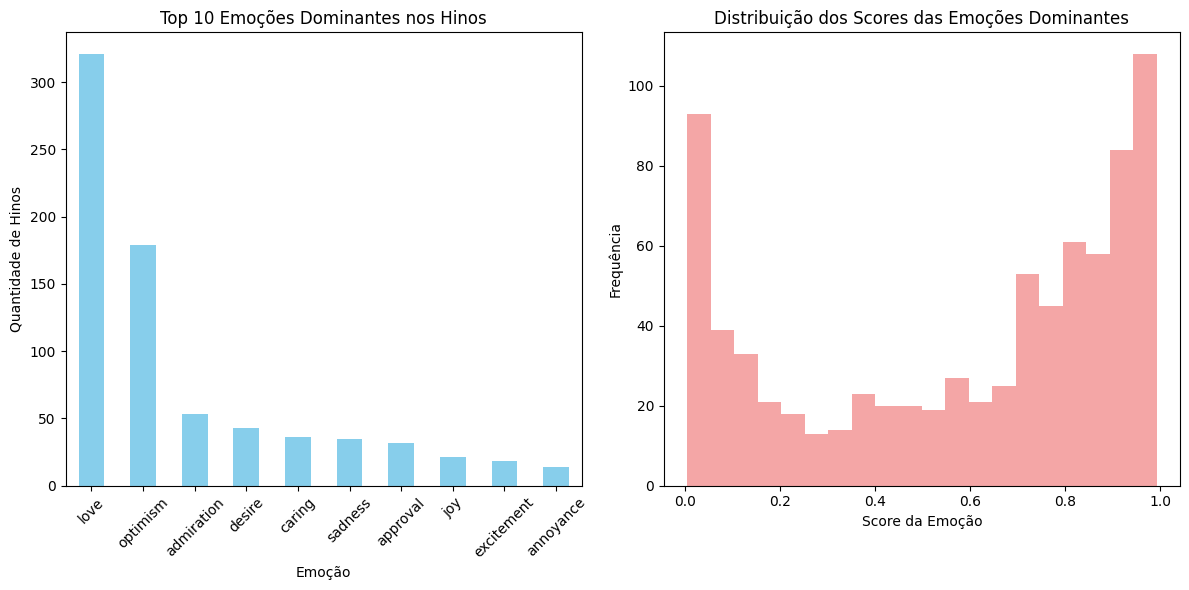


=== ESTATÍSTICAS DAS EMOÇÕES (sem neutral em foco) ===
Total de hinos analisados: 795
Hinos com erro no processamento: 0
Hinos com erro no processamento (sem neutral): 0
Score médio das emoções dominantes: 0.581

Top 10 emoções mais frequentes:
 1. love           : 321 hinos (40.4%)
 2. optimism       : 179 hinos (22.5%)
 3. admiration     :  53 hinos ( 6.7%)
 4. desire         :  43 hinos ( 5.4%)
 5. caring         :  36 hinos ( 4.5%)
 6. sadness        :  35 hinos ( 4.4%)
 7. approval       :  32 hinos ( 4.0%)
 8. joy            :  21 hinos ( 2.6%)
 9. excitement     :  18 hinos ( 2.3%)
10. annoyance      :  14 hinos ( 1.8%)

=== EXEMPLOS POR EMOÇÃO ===

LOVE (score: 0.667):
  Hino: CLAMO A TI
  Texto: CLAMO A TI, Ó MEU SENHOR, CLAMO A TI, MEU SALVADOR, PELO TEU SANGUE, QUE É VIDA, Ó BENDITO, VEM ME L...

OPTIMISM (score: 0.886):
  Hino: AQUILO QUE FUI NÃO SOU MAIS
  Texto: AQUILO QUE FUI NÃO SOU MAIS, NEM SOU TUDO O QUE DEVO SER; JÁ SOU PELA GRAÇA O QUE SOU E AO VÊ-LO EST...

ADMIR

In [5]:
# Análise e visualização dos resultados de emoções
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Extrair a emoção dominante de cada hino
emocoes_dominantes = []
scores_dominantes = []
emocoes_dominantes_sem_neutral = []
scores_dominantes_sem_neutral = []

for emocoes in hinos_analise["emocoes"]:
    if emocoes:
        top_emocao = max(emocoes.items(), key=lambda x: x[1])
        emocoes_dominantes.append(top_emocao[0])
        scores_dominantes.append(top_emocao[1])

        # Remove 'neutral' se existir
        emocoes_filtrado = {k: v for k, v in emocoes.items() if k != "neutral"}
        if emocoes_filtrado:
            top_emocao = max(emocoes_filtrado.items(), key=lambda x: x[1])
            emocoes_dominantes_sem_neutral.append(top_emocao[0])
            scores_dominantes_sem_neutral.append(top_emocao[1])
        else:
            emocoes_dominantes_sem_neutral.append("unknown")
            scores_dominantes_sem_neutral.append(0.0)
    else:
        emocoes_dominantes.append("unknown")
        scores_dominantes.append(0.0)

        emocoes_dominantes_sem_neutral.append("unknown")
        scores_dominantes_sem_neutral.append(0.0)

hinos_analise["emocao_dominante"] = emocoes_dominantes
hinos_analise["score_dominante"] = scores_dominantes
hinos_analise["emocao_dominante_sem_neutral"] = emocoes_dominantes_sem_neutral
hinos_analise["score_dominante_sem_neutral"] = scores_dominantes_sem_neutral

# 1. Distribuição das emoções dominantes
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
emocao_counts = pd.Series(emocoes_dominantes_sem_neutral).value_counts().head(10)
emocao_counts.plot(kind="bar", color="skyblue")
plt.title("Top 10 Emoções Dominantes nos Hinos")
plt.xlabel("Emoção")
plt.ylabel("Quantidade de Hinos")
plt.xticks(rotation=45)

# 2. Distribuição dos scores das emoções dominantes
plt.subplot(1, 2, 2)
plt.hist(scores_dominantes_sem_neutral, bins=20, color="lightcoral", alpha=0.7)
plt.title("Distribuição dos Scores das Emoções Dominantes")
plt.xlabel("Score da Emoção")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

# 3. Estatísticas das emoções
print("\n=== ESTATÍSTICAS DAS EMOÇÕES (sem neutral em foco) ===")
print(f"Total de hinos analisados: {len(hinos_analise)}")
print(f"Hinos com erro no processamento: {emocoes_dominantes.count('unknown')}")
print(
    f"Hinos com erro no processamento (sem neutral): {emocoes_dominantes_sem_neutral.count('unknown')}"
)
print(
    f"Score médio das emoções dominantes: {np.mean([s for s in scores_dominantes_sem_neutral if s > 0]):.3f}"
)

print("\nTop 10 emoções mais frequentes:")
for i, (emocao, count) in enumerate(emocao_counts.head(10).items(), 1):
    percentage = (count / len(hinos_analise)) * 100
    print(f"{i:2d}. {emocao:15s}: {count:3d} hinos ({percentage:4.1f}%)")

# 4. Exemplos de hinos por emoção dominante
print("\n=== EXEMPLOS POR EMOÇÃO ===")
for emocao in emocao_counts.head(5).index:
    hinos_emocao = hinos_analise[hinos_analise["emocao_dominante"] == emocao]
    exemplo = hinos_emocao.iloc[0]
    print(f"\n{emocao.upper()} (score: {exemplo['score_dominante']:.3f}):")
    print(f"  Hino: {exemplo['nome']}")
    print(f"  Texto: {exemplo['texto_limpo'][:100]}...")

# Análises estatísticas profundas

1. ANÁLISE DE DISTRIBUIÇÃO CONJUNTA DE EMOÇÕES

--- Correlação entre Emoções ---


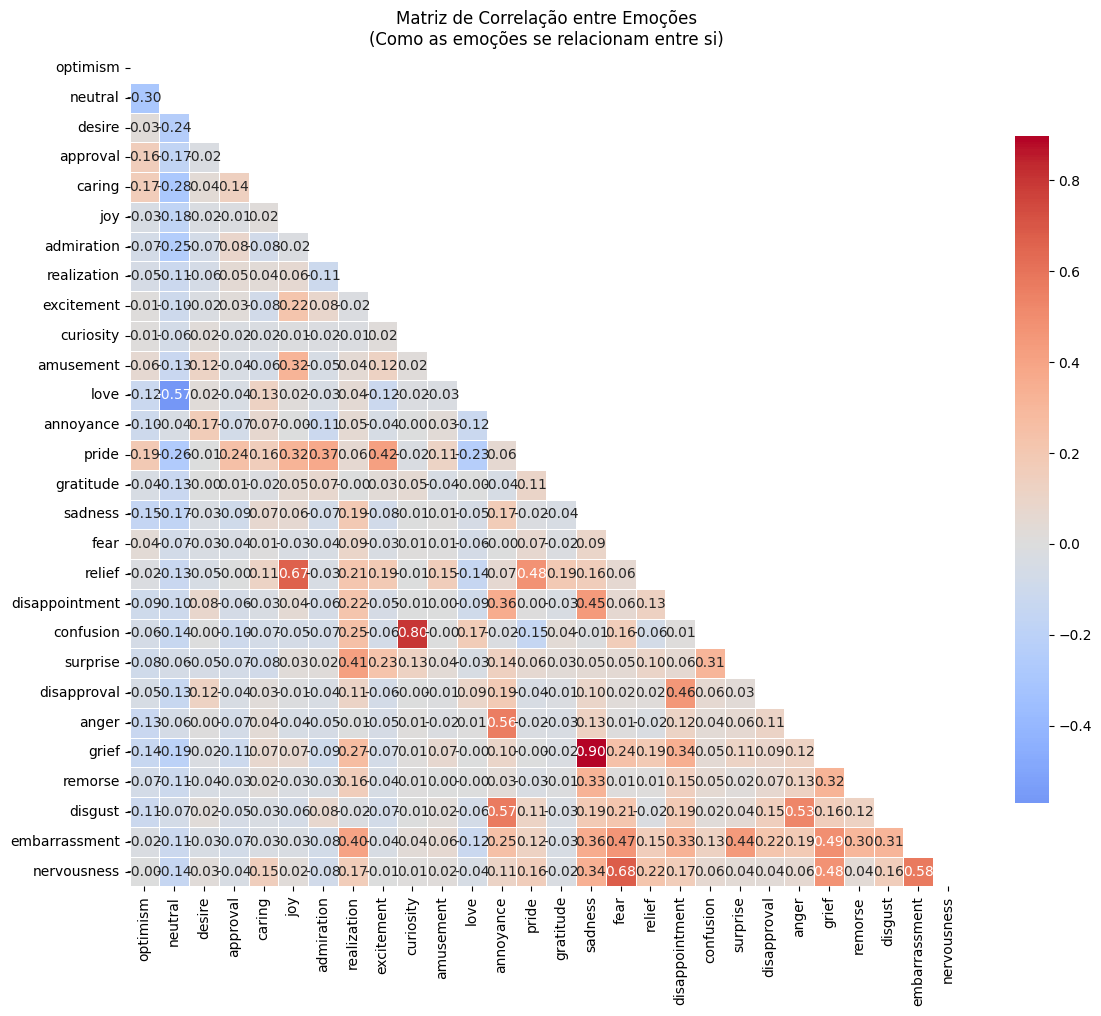


Pares de emoções MAIS correlacionadas (positivamente):
 1. grief        ↔ sadness     : 0.897
 2. sadness      ↔ grief       : 0.897
 3. confusion    ↔ curiosity   : 0.797
 4. curiosity    ↔ confusion   : 0.797
 5. fear         ↔ nervousness : 0.682
 6. nervousness  ↔ fear        : 0.682
 7. joy          ↔ relief      : 0.669
 8. relief       ↔ joy         : 0.669
 9. embarrassment ↔ nervousness : 0.579
10. nervousness  ↔ embarrassment: 0.579

Pares de emoções MENOS correlacionadas (negativamente):
 1. neutral      ↔ admiration  : -0.248
 2. admiration   ↔ neutral     : -0.248
 3. neutral      ↔ pride       : -0.258
 4. pride        ↔ neutral     : -0.258
 5. neutral      ↔ caring      : -0.285
 6. caring       ↔ neutral     : -0.285
 7. optimism     ↔ neutral     : -0.299
 8. neutral      ↔ optimism    : -0.299
 9. love         ↔ neutral     : -0.570
10. neutral      ↔ love        : -0.570


In [6]:
# ===== ANÁLISES ESTATÍSTICAS PROFUNDAS =====

# 1. ANÁLISE DE DISTRIBUIÇÃO CONJUNTA DE EMOÇÕES
print("=" * 80)
print("1. ANÁLISE DE DISTRIBUIÇÃO CONJUNTA DE EMOÇÕES")
print("=" * 80)

# Criar dataframe com todas as emoções expandidas
emocoes_por_hino = []
for emocoes in hinos_analise["emocoes"]:
    if emocoes:
        emocoes_por_hino.append(emocoes)
    else:
        emocoes_por_hino.append({})

emo_df_completo = pd.DataFrame(emocoes_por_hino).fillna(0)

# Matriz de correlação entre emoções
print("\n--- Correlação entre Emoções ---")
correlacao_emocoes = emo_df_completo.corr()

# Visualizar matriz de correlação
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlacao_emocoes, dtype=bool))
sns.heatmap(
    correlacao_emocoes,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title(
    "Matriz de Correlação entre Emoções\n(Como as emoções se relacionam entre si)"
)
plt.tight_layout()
plt.show()

# Identificar pares de emoções mais correlacionadas
print("\nPares de emoções MAIS correlacionadas (positivamente):")
corr_flat = correlacao_emocoes.unstack()
corr_sorted = corr_flat.sort_values(ascending=False)
# Remover auto-correlações (diagonal)
corr_sorted = corr_sorted[corr_sorted < 0.999]
for i, (pair, valor) in enumerate(corr_sorted.head(10).items(), 1):
    print(f"{i:2d}. {pair[0]:12s} ↔ {pair[1]:12s}: {valor:.3f}")

print("\nPares de emoções MENOS correlacionadas (negativamente):")
for i, (pair, valor) in enumerate(corr_sorted.tail(10).items(), 1):
    print(f"{i:2d}. {pair[0]:12s} ↔ {pair[1]:12s}: {valor:.3f}")


2. ANÁLISE DE DIVERSIDADE EMOCIONAL



--- Estatísticas de Diversidade Emocional ---
Entropia média: 1.272
Entropia mínima: 0.206
Entropia máxima: 2.603

Concentração média: 0.617


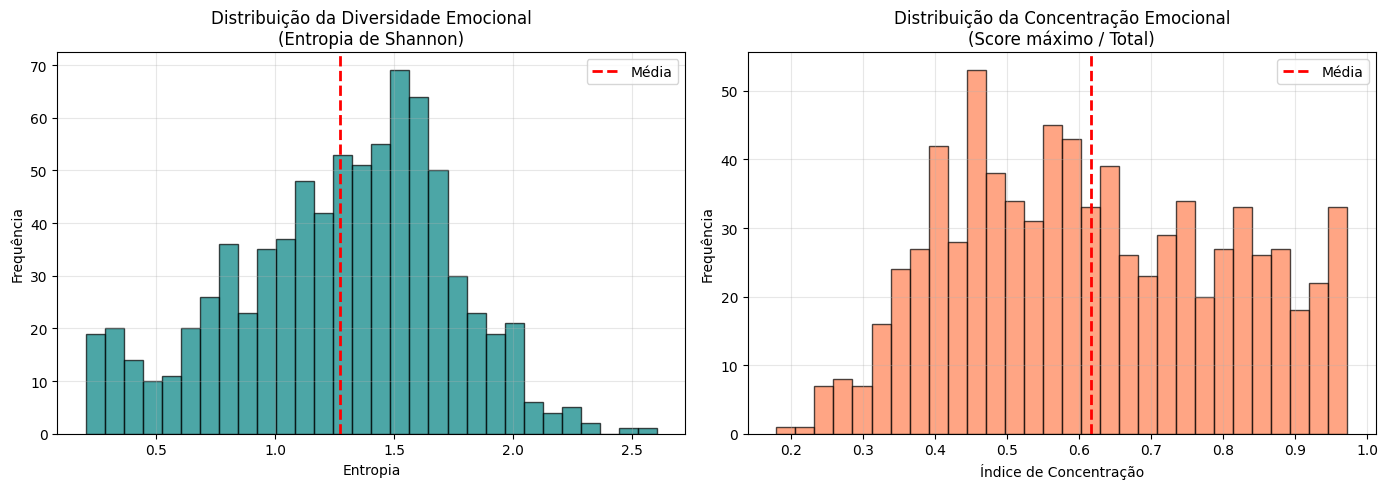


--- Hinos Mais DIVERSOS Emocionalmente (múltiplas emoções balanceadas) ---

1. EU NÃO SABERIA CAMINHAR
   Entropia: 2.603
   Top 3 emoções: neutral(0.08), approval(0.07), realization(0.06)

2. SE NÃO FOSSE O SENHOR
   Entropia: 2.520
   Top 3 emoções: neutral(0.13), caring(0.12), admiration(0.09)

3. JESUS, SENHOR, ME CHEGO A TI (EU VENHO COMO ESTOU)
   Entropia: 2.325
   Top 3 emoções: sadness(0.35), love(0.18), remorse(0.09)

4. NO GETSÊMANI
   Entropia: 2.312
   Top 3 emoções: joy(0.31), neutral(0.26), excitement(0.22)

5. NO SERVIÇO DO MEU REI EU SOU FELIZ
   Entropia: 2.251
   Top 3 emoções: sadness(0.32), caring(0.20), joy(0.20)

--- Hinos Mais CONCENTRADOS Emocionalmente (emoção dominante forte) ---

1. COMO AS ÁGUAS
   Concentração: 0.972
   Emoção dominante: neutral (0.992)

2. PÕE TEU SANGUE SOBRE MIM
   Concentração: 0.972
   Emoção dominante: neutral (0.992)

3. INVOCA-ME E TE RESPONDEREI
   Concentração: 0.972
   Emoção dominante: neutral (0.992)

4. SOMENTE PELA FÉ A OBR

In [7]:
from scipy.stats import entropy

# 2. ANÁLISE DE DIVERSIDADE EMOCIONAL
print("\n" + "=" * 80)
print("2. ANÁLISE DE DIVERSIDADE EMOCIONAL")
print("=" * 80)


def calcular_diversidade_emocional(emocoes):
    """Calcula a entropia de Shannon para medir diversidade emocional"""
    if not emocoes:
        return 0.0
    scores = np.array(list(emocoes.values()))
    # Normalizar para que somem 1 (distribuição de probabilidade)
    if scores.sum() > 0:
        probs = scores / scores.sum()
        return entropy(probs)
    return 0.0


def calcular_concentracao_emocional(emocoes):
    """Calcula índice de concentração (Gini simplificado)"""
    if not emocoes:
        return 0.0
    scores = np.array(list(emocoes.values()))
    if scores.sum() == 0:
        return 0.0
    # Score máximo / soma total (quanto maior, mais concentrado)
    return scores.max() / scores.sum()


# Aplicar métricas
hinos_analise["diversidade_emocional"] = hinos_analise["emocoes"].apply(
    calcular_diversidade_emocional
)
hinos_analise["concentracao_emocional"] = hinos_analise["emocoes"].apply(
    calcular_concentracao_emocional
)

print("\n--- Estatísticas de Diversidade Emocional ---")
print(f"Entropia média: {hinos_analise['diversidade_emocional'].mean():.3f}")
print(f"Entropia mínima: {hinos_analise['diversidade_emocional'].min():.3f}")
print(f"Entropia máxima: {hinos_analise['diversidade_emocional'].max():.3f}")
print(f"\nConcentração média: {hinos_analise['concentracao_emocional'].mean():.3f}")

# Visualizar distribuição
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    hinos_analise["diversidade_emocional"],
    bins=30,
    color="teal",
    alpha=0.7,
    edgecolor="black",
)
axes[0].axvline(
    hinos_analise["diversidade_emocional"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Média",
)
axes[0].set_title("Distribuição da Diversidade Emocional\n(Entropia de Shannon)")
axes[0].set_xlabel("Entropia")
axes[0].set_ylabel("Frequência")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(
    hinos_analise["concentracao_emocional"],
    bins=30,
    color="coral",
    alpha=0.7,
    edgecolor="black",
)
axes[1].axvline(
    hinos_analise["concentracao_emocional"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Média",
)
axes[1].set_title("Distribuição da Concentração Emocional\n(Score máximo / Total)")
axes[1].set_xlabel("Índice de Concentração")
axes[1].set_ylabel("Frequência")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Exemplos de hinos mais diversos vs. mais concentrados
print("\n--- Hinos Mais DIVERSOS Emocionalmente (múltiplas emoções balanceadas) ---")
mais_diversos = hinos_analise.nlargest(5, "diversidade_emocional")
for i, row in enumerate(mais_diversos.iterrows(), 1):
    idx, hino = row
    print(f"\n{i}. {hino['nome']}")
    print(f"   Entropia: {hino['diversidade_emocional']:.3f}")
    if hino["emocoes"]:
        top_3 = sorted(hino["emocoes"].items(), key=lambda x: x[1], reverse=True)[:3]
        print(f"   Top 3 emoções: {', '.join([f'{e[0]}({e[1]:.2f})' for e in top_3])}")

print("\n--- Hinos Mais CONCENTRADOS Emocionalmente (emoção dominante forte) ---")
mais_concentrados = hinos_analise.nlargest(5, "concentracao_emocional")
for i, row in enumerate(mais_concentrados.iterrows(), 1):
    idx, hino = row
    print(f"\n{i}. {hino['nome']}")
    print(f"   Concentração: {hino['concentracao_emocional']:.3f}")
    if hino["emocoes"]:
        top_emocao = max(hino["emocoes"].items(), key=lambda x: x[1])
        print(f"   Emoção dominante: {top_emocao[0]} ({top_emocao[1]:.3f})")


3. ANÁLISE TEMPORAL/SEQUENCIAL

--- Distribuição de Emoções por Posição na Coletânea ---

Início (25%):
  Emoção mais comum: love
  Top 3 emoções:
    - love: 91 hinos
    - optimism: 20 hinos
    - sadness: 16 hinos

Meio-Início (50%):
  Emoção mais comum: love
  Top 3 emoções:
    - love: 84 hinos
    - optimism: 53 hinos
    - caring: 17 hinos

Meio-Fim (75%):
  Emoção mais comum: love
  Top 3 emoções:
    - love: 70 hinos
    - optimism: 68 hinos
    - desire: 20 hinos

Fim (100%):
  Emoção mais comum: love
  Top 3 emoções:
    - love: 76 hinos
    - optimism: 38 hinos
    - admiration: 28 hinos


<Figure size 1400x600 with 0 Axes>

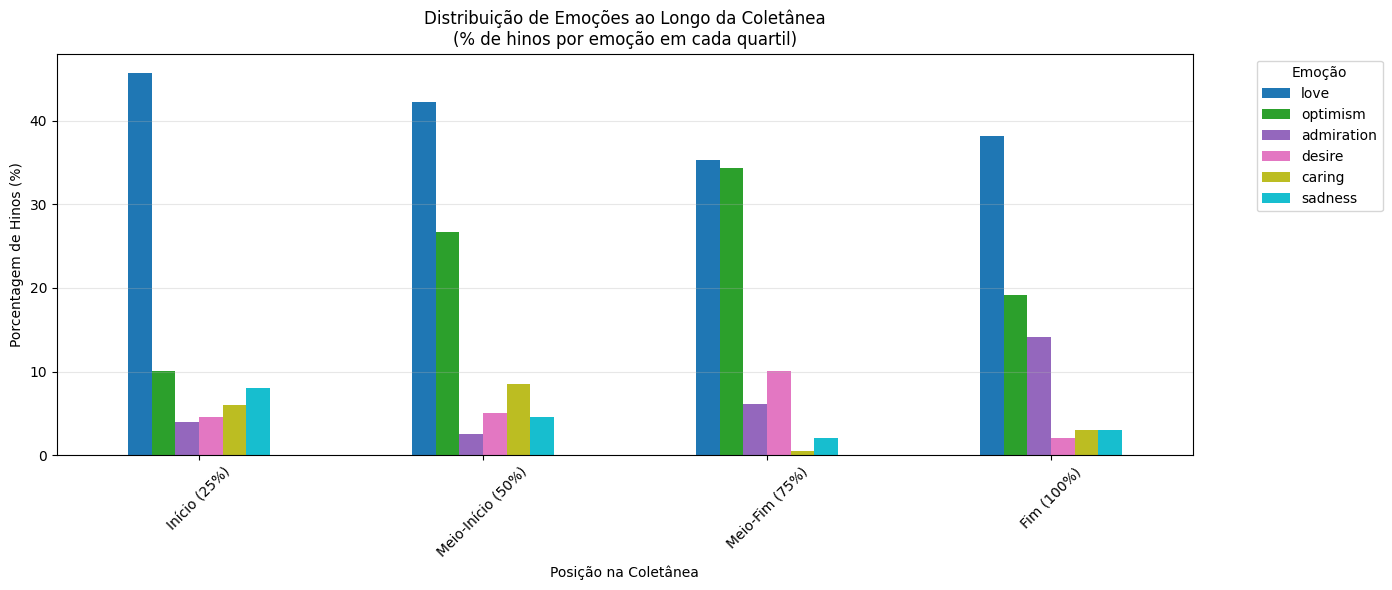


ANÁLISES ESTATÍSTICAS PROFUNDAS CONCLUÍDAS!


In [8]:
# 3. ANÁLISE TEMPORAL/SEQUENCIAL
print("\n" + "=" * 80)
print("3. ANÁLISE TEMPORAL/SEQUENCIAL")
print("=" * 80)

# Usar índice como proxy
hinos_analise["posicao_percentil"] = pd.qcut(
    hinos_analise.index,
    q=4,
    labels=["Início (25%)", "Meio-Início (50%)", "Meio-Fim (75%)", "Fim (100%)"],
    duplicates="drop",
)

print("\n--- Distribuição de Emoções por Posição na Coletânea ---")

# Emoção dominante por quartil
for quartil in ["Início (25%)", "Meio-Início (50%)", "Meio-Fim (75%)", "Fim (100%)"]:
    hinos_quartil = hinos_analise[hinos_analise["posicao_percentil"] == quartil]
    emocao_mais_comum = (
        hinos_quartil["emocao_dominante_sem_neutral"].mode()[0]
        if len(hinos_quartil) > 0
        else "N/A"
    )
    print(f"\n{quartil}:")
    print(f"  Emoção mais comum: {emocao_mais_comum}")
    print(f"  Top 3 emoções:")
    top3 = hinos_quartil["emocao_dominante_sem_neutral"].value_counts().head(3)
    for emocao, count in top3.items():
        print(f"    - {emocao}: {count} hinos")

# Visualização
plt.figure(figsize=(14, 6))

# Preparar dados para visualização
posicao_emocao = (
    pd.crosstab(
        hinos_analise["posicao_percentil"],
        hinos_analise["emocao_dominante_sem_neutral"],
        normalize="index",
    )
    * 100
)

# Selecionar top 6 emoções mais comuns
top_emocoes = hinos_analise["emocao_dominante_sem_neutral"].value_counts().head(6).index
posicao_emocao_top = posicao_emocao[top_emocoes]

posicao_emocao_top.plot(kind="bar", stacked=False, figsize=(14, 6), colormap="tab10")
plt.title(
    "Distribuição de Emoções ao Longo da Coletânea\n(% de hinos por emoção em cada quartil)"
)
plt.xlabel("Posição na Coletânea")
plt.ylabel("Porcentagem de Hinos (%)")
plt.legend(title="Emoção", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("ANÁLISES ESTATÍSTICAS PROFUNDAS CONCLUÍDAS!")
print("=" * 80)

# Análises comparativas

ANÁLISES COMPARATIVAS - SUBSTITUINDO 'COM/SEM NEUTRAL'

1. SCORE LÍQUIDO EMOCIONAL
--------------------------------------------------------------------------------
Score líquido médio: 0.243
Score líquido mínimo: -0.989
Score líquido máximo: 0.987


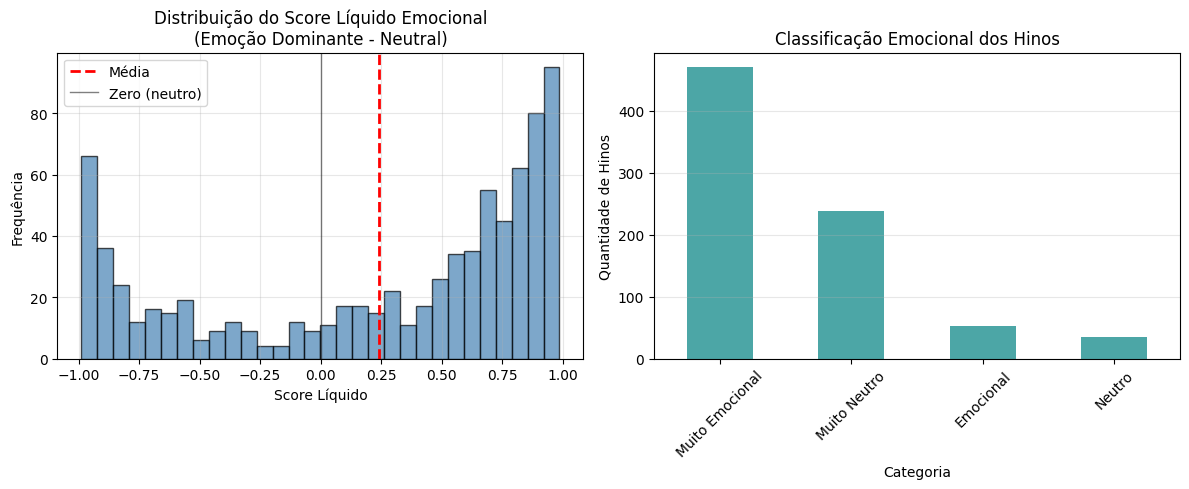


--- Hinos MAIS EMOCIONALMENTE CARREGADOS (score líquido alto) ---
1. GRANDE É O SENHOR E MUI DIGNO DE SER LOUVADO
   Score líquido: 0.987 | Emoção: admiration
   Neutral: 0.003 | admiration: 0.990
2. LINDO! LINDO! LINDO!
   Score líquido: 0.985 | Emoção: admiration
   Neutral: 0.004 | admiration: 0.989
3. GRAÇAS DOU, Ó SENHOR
   Score líquido: 0.985 | Emoção: gratitude
   Neutral: 0.008 | gratitude: 0.992
4. DEIXA-ME CHORAR
   Score líquido: 0.981 | Emoção: love
   Neutral: 0.005 | love: 0.986
5. POR AMOR
   Score líquido: 0.979 | Emoção: love
   Neutral: 0.009 | love: 0.987

--- Hinos MAIS NEUTROS (score líquido baixo/negativo) ---
1. SOMENTE PELA FÉ A OBRA DE DEUS
   Score líquido: -0.989
   Neutral: 0.993
2. É PRECISO CONFIAR E BUSCAR A DEUS
   Score líquido: -0.988
   Neutral: 0.992
3. Ó PASTOR DE ISRAEL
   Score líquido: -0.988
   Neutral: 0.992
4. INVOCA-ME E TE RESPONDEREI
   Score líquido: -0.988
   Neutral: 0.992
5. O ANJO DO SENHOR ESTÁ PASSEANDO
   Score líquido: -0.988
   

In [9]:
# ===== ANÁLISES COMPARATIVAS MELHORADAS =====

print("=" * 80)
print("ANÁLISES COMPARATIVAS - SUBSTITUINDO 'COM/SEM NEUTRAL'")
print("=" * 80)

# 1. SCORE LÍQUIDO EMOCIONAL (força emocional relativa ao neutral)
print("\n1. SCORE LÍQUIDO EMOCIONAL")
print("-" * 80)


def calcular_score_liquido(emocoes):
    """Calcula a diferença entre emoção dominante (não-neutral) e neutral"""
    if not emocoes:
        return 0.0, "unknown"

    score_neutral = emocoes.get("neutral", 0.0)
    emocoes_sem_neutral = {k: v for k, v in emocoes.items() if k != "neutral"}

    if emocoes_sem_neutral:
        top_emocao, top_score = max(emocoes_sem_neutral.items(), key=lambda x: x[1])
        return top_score - score_neutral, top_emocao
    return 0.0, "unknown"


# Aplicar cálculo
scores_liquidos = hinos_analise["emocoes"].apply(calcular_score_liquido)
hinos_analise["score_liquido"] = scores_liquidos.apply(lambda x: x[0])
hinos_analise["emocao_dominante_nao_neutral"] = scores_liquidos.apply(lambda x: x[1])

print(f"Score líquido médio: {hinos_analise['score_liquido'].mean():.3f}")
print(f"Score líquido mínimo: {hinos_analise['score_liquido'].min():.3f}")
print(f"Score líquido máximo: {hinos_analise['score_liquido'].max():.3f}")

# Visualizar distribuição
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(
    hinos_analise["score_liquido"],
    bins=30,
    color="steelblue",
    alpha=0.7,
    edgecolor="black",
)
plt.axvline(
    hinos_analise["score_liquido"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Média",
)
plt.axvline(
    0, color="black", linestyle="-", linewidth=1, alpha=0.5, label="Zero (neutro)"
)
plt.title("Distribuição do Score Líquido Emocional\n(Emoção Dominante - Neutral)")
plt.xlabel("Score Líquido")
plt.ylabel("Frequência")
plt.legend()
plt.grid(alpha=0.3)

# Hinos mais emocionalmente carregados vs. mais neutros
plt.subplot(1, 2, 2)
bins = [-1, -0.1, 0.1, 0.3, 1]
labels = ["Muito Neutro", "Neutro", "Emocional", "Muito Emocional"]
hinos_analise["categoria_emocional"] = pd.cut(
    hinos_analise["score_liquido"], bins=bins, labels=labels
)
hinos_analise["categoria_emocional"].value_counts().plot(
    kind="bar", color="teal", alpha=0.7
)
plt.title("Classificação Emocional dos Hinos")
plt.xlabel("Categoria")
plt.ylabel("Quantidade de Hinos")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Exemplos
print("\n--- Hinos MAIS EMOCIONALMENTE CARREGADOS (score líquido alto) ---")
mais_emocionais = hinos_analise.nlargest(5, "score_liquido")
for i, row in enumerate(mais_emocionais.iterrows(), 1):
    idx, hino = row
    print(f"{i}. {hino['nome'][:50]}")
    print(
        f"   Score líquido: {hino['score_liquido']:.3f} | Emoção: {hino['emocao_dominante_nao_neutral']}"
    )
    if hino["emocoes"]:
        print(
            f"   Neutral: {hino['emocoes'].get('neutral', 0):.3f} | {hino['emocao_dominante_nao_neutral']}: {max([v for k,v in hino['emocoes'].items() if k != 'neutral'], default=0):.3f}"
        )

print("\n--- Hinos MAIS NEUTROS (score líquido baixo/negativo) ---")
mais_neutros = hinos_analise.nsmallest(5, "score_liquido")
for i, row in enumerate(mais_neutros.iterrows(), 1):
    idx, hino = row
    print(f"{i}. {hino['nome'][:50]}")
    print(f"   Score líquido: {hino['score_liquido']:.3f}")
    if hino["emocoes"]:
        print(f"   Neutral: {hino['emocoes'].get('neutral', 0):.3f}")



2. AGRUPAMENTO DE EMOÇÕES POR CATEGORIA
--------------------------------------------------------------------------------

--- Distribuição por Categoria Emocional ---
categoria_dominante
positivas    495
neutras      264
negativas     36
Name: count, dtype: int64


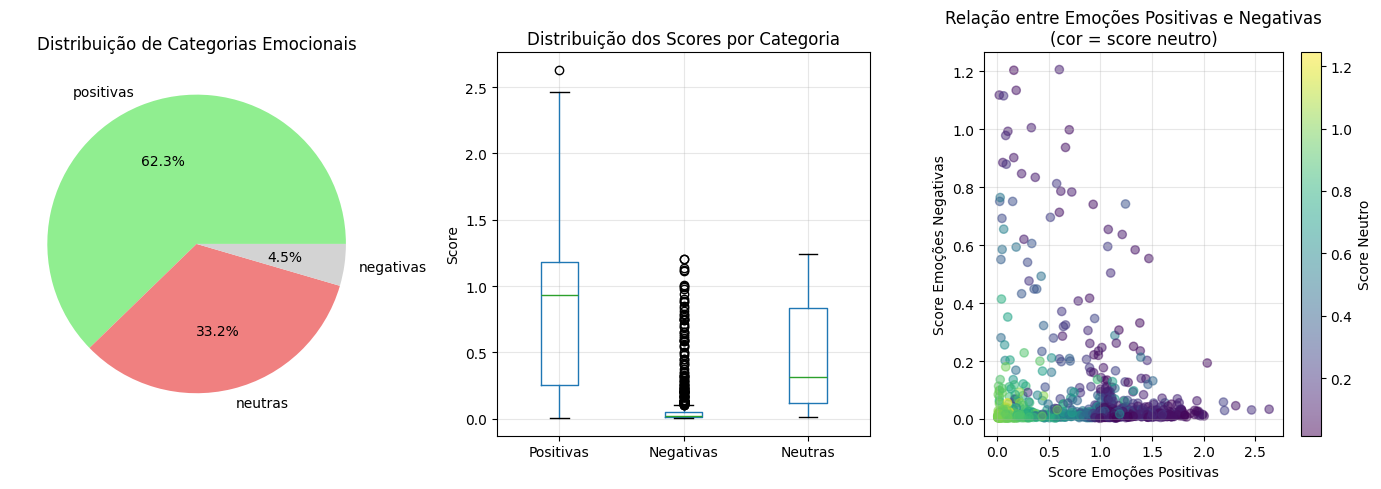


--- Estatísticas por Categoria ---
Score médio positivas: 0.813
Score médio negativas: 0.080
Score médio neutras: 0.443

Valência emocional média: 0.734
  (Valores positivos = mais alegre/positivo, negativos = mais triste/negativo)

ANÁLISES COMPARATIVAS CONCLUÍDAS!


In [10]:
# 2. AGRUPAMENTO DE EMOÇÕES POR CATEGORIA
print("\n\n2. AGRUPAMENTO DE EMOÇÕES POR CATEGORIA")
print("-" * 80)

# Definir categorias (ajustar conforme as emoções do modelo)
CATEGORIAS_EMOCOES = {
    "positivas": [
        "joy",
        "love",
        "admiration",
        "approval",
        "caring",
        "excitement",
        "gratitude",
        "optimism",
        "pride",
        "relief",
    ],
    "negativas": [
        "anger",
        "disgust",
        "fear",
        "sadness",
        "disappointment",
        "embarrassment",
        "grief",
        "nervousness",
        "remorse",
    ],
    "neutras": [
        "neutral",
        "realization",
        "surprise",
        "confusion",
        "curiosity",
        "desire",
        "amusement",
    ],
}


def calcular_score_categoria(emocoes, categoria):
    """Soma os scores de todas as emoções de uma categoria"""
    if not emocoes:
        return 0.0
    emocoes_da_categoria = CATEGORIAS_EMOCOES.get(categoria, [])
    return sum(emocoes.get(emocao, 0.0) for emocao in emocoes_da_categoria)


# Aplicar para cada categoria
for categoria in ["positivas", "negativas", "neutras"]:
    hinos_analise[f"score_{categoria}"] = hinos_analise["emocoes"].apply(
        lambda x: calcular_score_categoria(x, categoria)
    )


# Categoria dominante
def categoria_dominante(row):
    scores = {
        "positivas": row["score_positivas"],
        "negativas": row["score_negativas"],
        "neutras": row["score_neutras"],
    }
    return max(scores.items(), key=lambda x: x[1])[0]


hinos_analise["categoria_dominante"] = hinos_analise.apply(categoria_dominante, axis=1)

# Visualizar
print("\n--- Distribuição por Categoria Emocional ---")
categoria_counts = hinos_analise["categoria_dominante"].value_counts()
print(categoria_counts)

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
categoria_counts.plot(
    kind="pie", autopct="%1.1f%%", colors=["lightgreen", "lightcoral", "lightgray"]
)
plt.title("Distribuição de Categorias Emocionais")
plt.ylabel("")

plt.subplot(1, 3, 2)
hinos_analise[["score_positivas", "score_negativas", "score_neutras"]].boxplot()
plt.title("Distribuição dos Scores por Categoria")
plt.ylabel("Score")
plt.xticks([1, 2, 3], ["Positivas", "Negativas", "Neutras"])
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
# Scatter: positivas vs negativas
plt.scatter(
    hinos_analise["score_positivas"],
    hinos_analise["score_negativas"],
    alpha=0.5,
    c=hinos_analise["score_neutras"],
    cmap="viridis",
)
plt.xlabel("Score Emoções Positivas")
plt.ylabel("Score Emoções Negativas")
plt.title("Relação entre Emoções Positivas e Negativas\n(cor = score neutro)")
plt.colorbar(label="Score Neutro")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas
print("\n--- Estatísticas por Categoria ---")
print(f"Score médio positivas: {hinos_analise['score_positivas'].mean():.3f}")
print(f"Score médio negativas: {hinos_analise['score_negativas'].mean():.3f}")
print(f"Score médio neutras: {hinos_analise['score_neutras'].mean():.3f}")

# Valência emocional geral (positivas - negativas)
hinos_analise["valencia_emocional"] = (
    hinos_analise["score_positivas"] - hinos_analise["score_negativas"]
)
print(f"\nValência emocional média: {hinos_analise['valencia_emocional'].mean():.3f}")
print(f"  (Valores positivos = mais alegre/positivo, negativos = mais triste/negativo)")

print("\n" + "=" * 80)
print("ANÁLISES COMPARATIVAS CONCLUÍDAS!")
print("=" * 80)

# Visualizações com gráficos de radar

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ===== VISUALIZAÇÕES AVANÇADAS: GRÁFICOS DE RADAR =====

print("=" * 80)
print("VISUALIZAÇÕES AVANÇADAS - GRÁFICOS DE RADAR/SPIDER")
print("=" * 80)


def criar_radar_chart(emocoes_dict, titulo, ax=None):
    """Cria um gráfico de radar para visualizar perfil emocional"""

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection="polar"))

    # Pegar todas as emoções (exceto neutral para focar nas principais)
    emocoes_filtradas = {k: v for k, v in emocoes_dict.items() if k != "neutral"}

    # Pegar top 8 emoções para não poluir o gráfico
    top_emocoes = sorted(emocoes_filtradas.items(), key=lambda x: x[1], reverse=True)[
        :8
    ]

    if not top_emocoes:
        return ax

    labels = [e[0] for e in top_emocoes]
    values = [e[1] for e in top_emocoes]

    # Número de variáveis
    num_vars = len(labels)

    # Calcular ângulos
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

    # Fechar o círculo
    values += values[:1]
    angles += angles[:1]
    labels += labels[:1]

    # Plot
    ax.plot(angles, values, "o-", linewidth=2, color="steelblue")
    ax.fill(angles, values, alpha=0.25, color="steelblue")

    # Labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels[:-1])
    ax.set_ylim(0, max(values) * 1.1)
    ax.set_title(titulo, pad=20, fontsize=12, fontweight="bold")
    ax.grid(True)

    return ax

VISUALIZAÇÕES AVANÇADAS - GRÁFICOS DE RADAR/SPIDER



1. Perfil Emocional MÉDIO de Todos os Hinos
--------------------------------------------------------------------------------


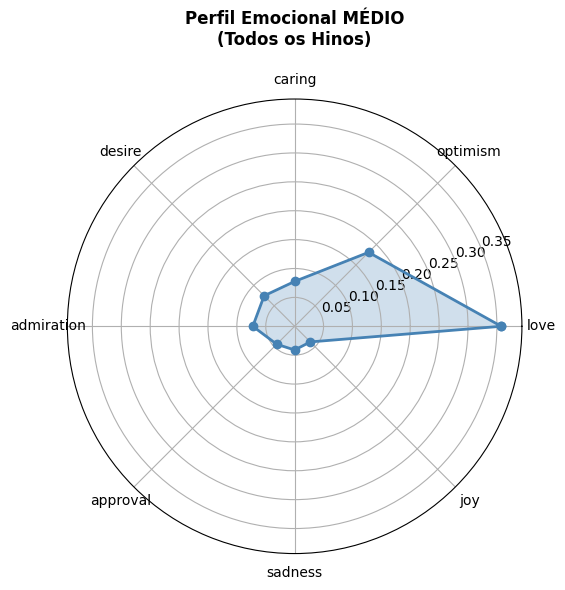

In [12]:
# 1. Radar do perfil emocional médio geral
print("\n1. Perfil Emocional MÉDIO de Todos os Hinos")
print("-" * 80)

# Calcular média de cada emoção
emocoes_medias = {}
for emocoes in hinos_analise["emocoes"]:
    if emocoes:
        for emocao, score in emocoes.items():
            if emocao not in emocoes_medias:
                emocoes_medias[emocao] = []
            emocoes_medias[emocao].append(score)

emocoes_medias_final = {k: np.mean(v) for k, v in emocoes_medias.items()}

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection="polar"))
criar_radar_chart(emocoes_medias_final, "Perfil Emocional MÉDIO\n(Todos os Hinos)", ax)
plt.tight_layout()
plt.show()


2. Perfis Emocionais por Categoria Dominante
--------------------------------------------------------------------------------


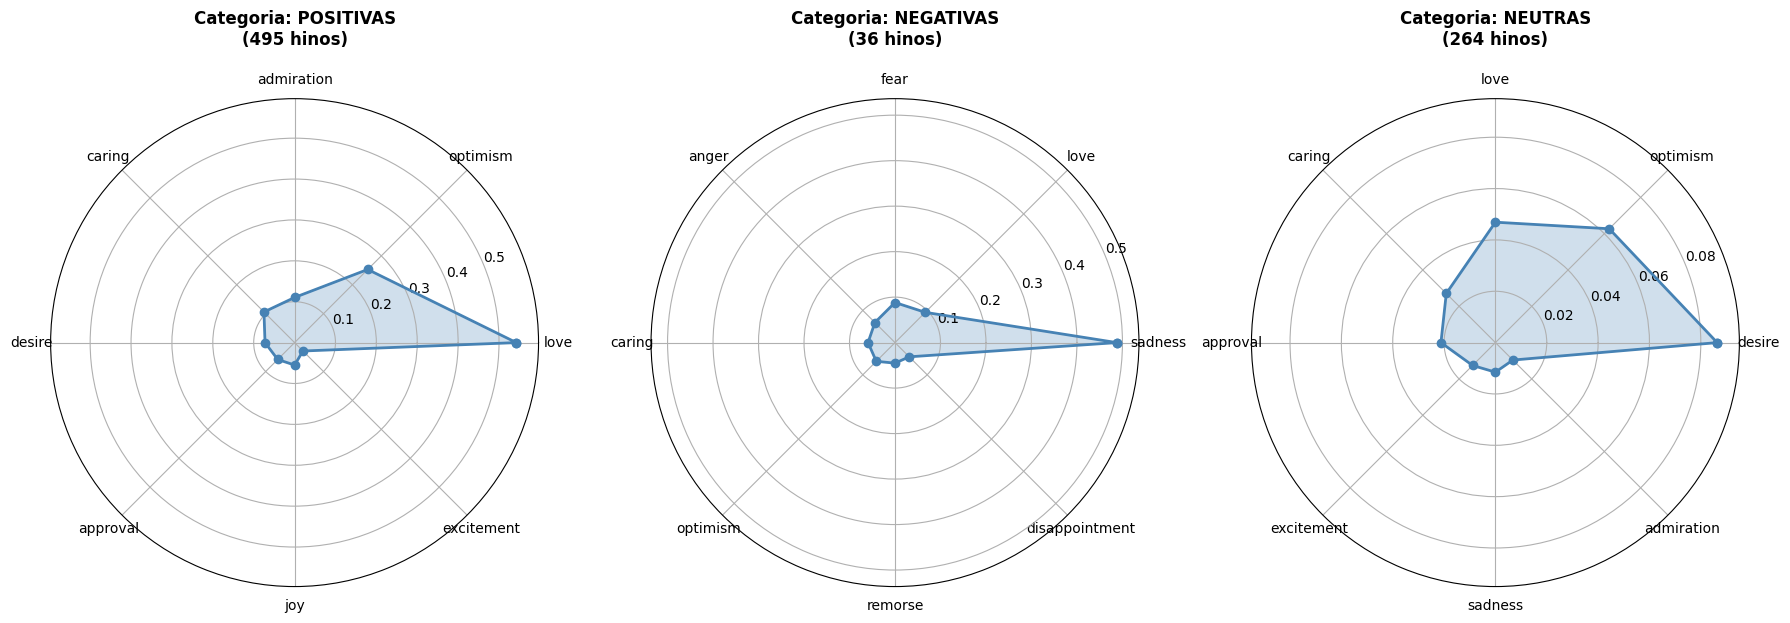

In [13]:
# 2. Radares comparando categorias emocionais
print("\n2. Perfis Emocionais por Categoria Dominante")
print("-" * 80)

# Verificar se as colunas necessárias existem, se não, criar
if "score_positivas" not in hinos_analise.columns:
    print("Criando colunas de scores por categoria...")

    # Definir categorias (ajustar conforme as emoções do modelo)
    CATEGORIAS_EMOCOES = {
        "positivas": [
            "joy",
            "love",
            "admiration",
            "approval",
            "caring",
            "excitement",
            "gratitude",
            "optimism",
            "pride",
            "relief",
        ],
        "negativas": [
            "anger",
            "disgust",
            "fear",
            "sadness",
            "disappointment",
            "embarrassment",
            "grief",
            "nervousness",
            "remorse",
        ],
        "neutras": [
            "neutral",
            "realization",
            "surprise",
            "confusion",
            "curiosity",
            "desire",
            "amusement",
        ],
    }

    def calcular_score_categoria(emocoes, categoria):
        """Soma os scores de todas as emoções de uma categoria"""
        if not emocoes:
            return 0.0
        emocoes_da_categoria = CATEGORIAS_EMOCOES.get(categoria, [])
        return sum(emocoes.get(emocao, 0.0) for emocao in emocoes_da_categoria)

    # Aplicar para cada categoria
    for categoria in ["positivas", "negativas", "neutras"]:
        hinos_analise[f"score_{categoria}"] = hinos_analise["emocoes"].apply(
            lambda x: calcular_score_categoria(x, categoria)
        )

    # Categoria dominante
    def categoria_dominante_func(row):
        scores = {
            "positivas": row["score_positivas"],
            "negativas": row["score_negativas"],
            "neutras": row["score_neutras"],
        }
        return max(scores.items(), key=lambda x: x[1])[0]

    hinos_analise["categoria_dominante"] = hinos_analise.apply(
        categoria_dominante_func, axis=1
    )
    print("Colunas de categorias criadas!")

# Verificar se score_liquido existe
if "score_liquido" not in hinos_analise.columns:
    print("Criando coluna score_liquido...")

    def calcular_score_liquido(emocoes):
        """Calcula a diferença entre emoção dominante (não-neutral) e neutral"""
        if not emocoes:
            return 0.0, "unknown"

        score_neutral = emocoes.get("neutral", 0.0)
        emocoes_sem_neutral = {k: v for k, v in emocoes.items() if k != "neutral"}

        if emocoes_sem_neutral:
            top_emocao, top_score = max(emocoes_sem_neutral.items(), key=lambda x: x[1])
            return top_score - score_neutral, top_emocao
        return 0.0, "unknown"

    scores_liquidos = hinos_analise["emocoes"].apply(calcular_score_liquido)
    hinos_analise["score_liquido"] = scores_liquidos.apply(lambda x: x[0])
    hinos_analise["emocao_dominante_nao_neutral"] = scores_liquidos.apply(
        lambda x: x[1]
    )
    print("Coluna score_liquido criada!")

fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(projection="polar"))

for i, categoria in enumerate(["positivas", "negativas", "neutras"]):
    hinos_categoria = hinos_analise[hinos_analise["categoria_dominante"] == categoria]

    if len(hinos_categoria) > 0:
        # Calcular perfil médio da categoria
        emocoes_cat = {}
        for emocoes in hinos_categoria["emocoes"]:
            if emocoes:
                for emocao, score in emocoes.items():
                    if emocao not in emocoes_cat:
                        emocoes_cat[emocao] = []
                    emocoes_cat[emocao].append(score)

        emocoes_cat_media = {k: np.mean(v) for k, v in emocoes_cat.items()}

        criar_radar_chart(
            emocoes_cat_media,
            f"Categoria: {categoria.upper()}\n({len(hinos_categoria)} hinos)",
            axes[i],
        )

plt.tight_layout()
plt.show()


3. Perfis Emocionais de Hinos Específicos
--------------------------------------------------------------------------------


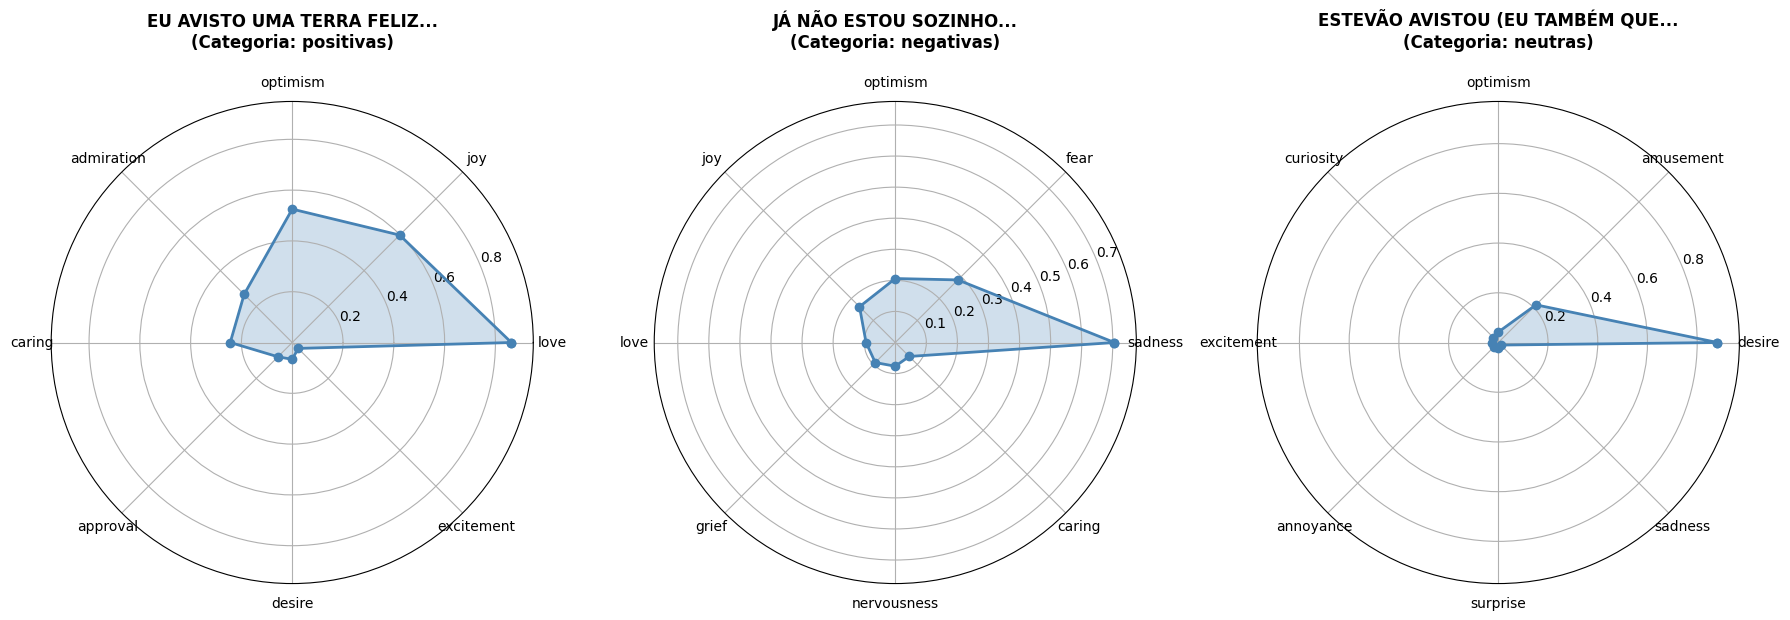


1. EU AVISTO UMA TERRA FELIZ
   Categoria: positivas
   Score líquido: 0.855

2. JÁ NÃO ESTOU SOZINHO
   Categoria: negativas
   Score líquido: 0.686

3. ESTEVÃO AVISTOU (EU TAMBÉM QUERO VER)
   Categoria: neutras
   Score líquido: 0.796

GRÁFICOS DE RADAR CONCLUÍDOS!


In [14]:
# 3. Radares de hinos individuais específicos
print("\n3. Perfis Emocionais de Hinos Específicos")
print("-" * 80)

# Pegar exemplos interessantes: um de cada categoria
exemplos = []
for categoria in ["positivas", "negativas", "neutras"]:
    hinos_cat = hinos_analise[hinos_analise["categoria_dominante"] == categoria]
    if len(hinos_cat) > 0:
        # Pegar o mais representativo (maior score da categoria)
        mais_representativo = hinos_cat.nlargest(1, f"score_{categoria}").iloc[0]
        exemplos.append(mais_representativo)

if len(exemplos) >= 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(projection="polar"))

    for i, hino in enumerate(exemplos):
        if hino["emocoes"]:
            criar_radar_chart(
                hino["emocoes"],
                f"{hino['nome'][:30]}...\n(Categoria: {hino['categoria_dominante']})",
                axes[i],
            )

    plt.tight_layout()
    plt.show()

    for i, hino in enumerate(exemplos, 1):
        print(f"\n{i}. {hino['nome']}")
        print(f"   Categoria: {hino['categoria_dominante']}")
        print(f"   Score líquido: {hino['score_liquido']:.3f}")

print("\n" + "=" * 80)
print("GRÁFICOS DE RADAR CONCLUÍDOS!")
print("=" * 80)

# Análises contextuais

ANÁLISES CONTEXTUAIS - RELAÇÃO COM OUTRAS VARIÁVEIS

1. Relação entre Emoções e Extensão do Texto
--------------------------------------------------------------------------------
Caracteres médio: 539
Palavras médio: 101

--- Distribuição de Categorias Emocionais por Tamanho do Texto ---
categoria_dominante  negativas  neutras  positivas
tamanho_texto                                     
Curto                     6.02    41.73      52.26
Médio                     4.07    26.67      69.26
Longo                     3.47    31.27      65.25


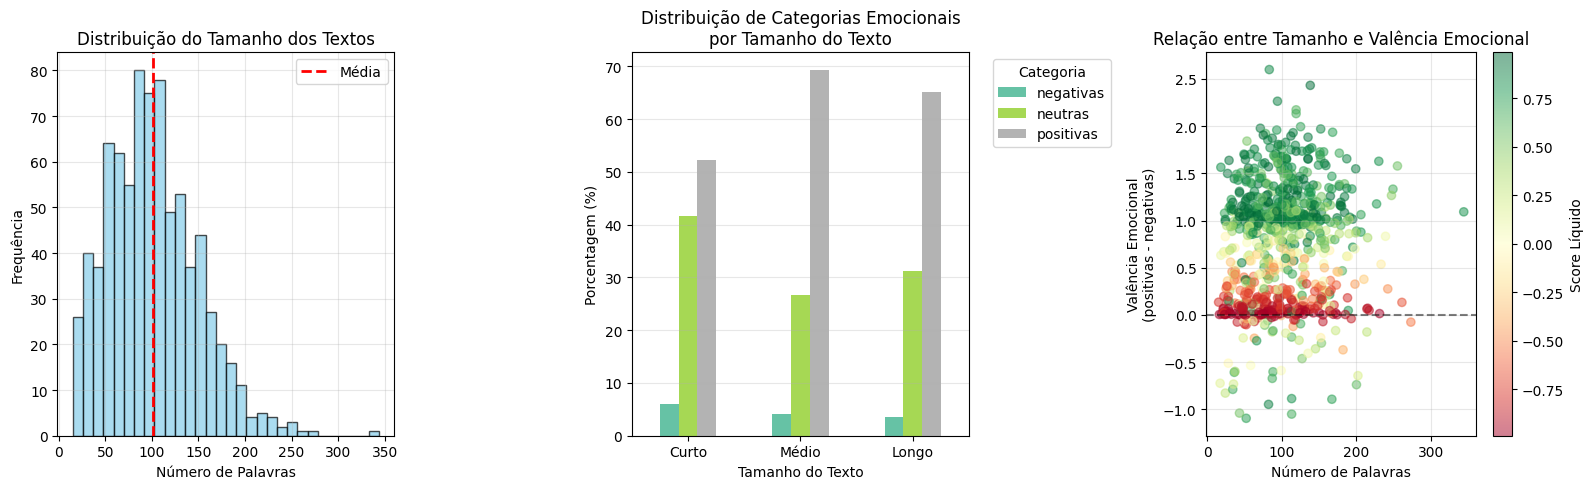


--- Correlação entre Tamanho do Texto e Métricas Emocionais ---
num_palavras             1.000000
diversidade_emocional    0.107119
valencia_emocional       0.102209
score_liquido            0.098023
Name: num_palavras, dtype: float64


In [15]:
# ===== ANÁLISES CONTEXTUAIS: RELAÇÃO COM OUTRAS VARIÁVEIS =====
print("=" * 80)
print("ANÁLISES CONTEXTUAIS - RELAÇÃO COM OUTRAS VARIÁVEIS")
print("=" * 80)

# 1. RELAÇÃO ENTRE EMOÇÕES E EXTENSÃO DO TEXTO
print("\n1. Relação entre Emoções e Extensão do Texto")
print("-" * 80)


hinos_analise["num_caracteres"] = hinos_analise["texto_limpo"].astype(str).str.len()
hinos_analise["num_palavras"] = (
    hinos_analise["texto_limpo"].astype(str).str.split().str.len()
)

print(f"Caracteres médio: {hinos_analise['num_caracteres'].mean():.0f}")
print(f"Palavras médio: {hinos_analise['num_palavras'].mean():.0f}")

# Criar bins de tamanho
hinos_analise["tamanho_texto"] = pd.qcut(
    hinos_analise["num_palavras"],
    q=3,
    labels=["Curto", "Médio", "Longo"],
    duplicates="drop",
)

# Análise por tamanho
print("\n--- Distribuição de Categorias Emocionais por Tamanho do Texto ---")
crosstab_tamanho = (
    pd.crosstab(
        hinos_analise["tamanho_texto"],
        hinos_analise["categoria_dominante"],
        normalize="index",
    )
    * 100
)
print(crosstab_tamanho.round(2))

# Visualização
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Distribuição de tamanhos
axes[0].hist(
    hinos_analise["num_palavras"],
    bins=30,
    color="skyblue",
    alpha=0.7,
    edgecolor="black",
)
axes[0].axvline(
    hinos_analise["num_palavras"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Média",
)
axes[0].set_title("Distribuição do Tamanho dos Textos")
axes[0].set_xlabel("Número de Palavras")
axes[0].set_ylabel("Frequência")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Emoções por tamanho
crosstab_tamanho.plot(kind="bar", ax=axes[1], stacked=False, colormap="Set2")
axes[1].set_title("Distribuição de Categorias Emocionais\npor Tamanho do Texto")
axes[1].set_xlabel("Tamanho do Texto")
axes[1].set_ylabel("Porcentagem (%)")
axes[1].legend(title="Categoria", bbox_to_anchor=(1.05, 1), loc="upper left")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(axis="y", alpha=0.3)

# 3. Scatter: tamanho vs valencia emocional
axes[2].scatter(
    hinos_analise["num_palavras"],
    hinos_analise["valencia_emocional"],
    alpha=0.5,
    c=hinos_analise["score_liquido"],
    cmap="RdYlGn",
)
axes[2].axhline(0, color="black", linestyle="--", alpha=0.5)
axes[2].set_xlabel("Número de Palavras")
axes[2].set_ylabel("Valência Emocional\n(positivas - negativas)")
axes[2].set_title("Relação entre Tamanho e Valência Emocional")
axes[2].grid(alpha=0.3)
plt.colorbar(axes[2].collections[0], ax=axes[2], label="Score Líquido")

plt.tight_layout()
plt.show()

# Correlação
corr_tamanho_valencia = hinos_analise[
    ["num_palavras", "valencia_emocional", "score_liquido", "diversidade_emocional"]
].corr()
print("\n--- Correlação entre Tamanho do Texto e Métricas Emocionais ---")
print(corr_tamanho_valencia["num_palavras"].sort_values(ascending=False))



2. Relação entre Emoções e Complexidade Léxica
--------------------------------------------------------------------------------
Complexidade léxica média: 0.567
(Valores próximos de 1 = muito variado, próximos de 0 = repetitivo)

--- Complexidade Léxica por Categoria Emocional ---
                         mean       std  count
categoria_dominante                           
negativas            0.578593  0.139599     36
neutras              0.576436  0.153756    264
positivas            0.560690  0.154088    495


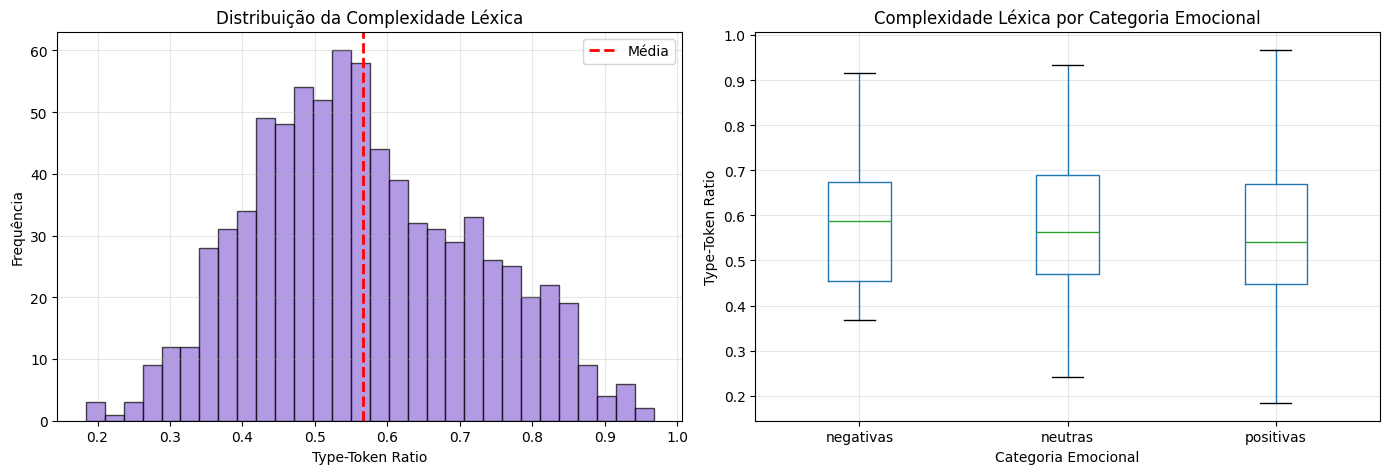


--- Correlação entre Complexidade Léxica e Métricas Emocionais ---
complexidade_lexica      1.000000
diversidade_emocional    0.029525
score_liquido           -0.027145
valencia_emocional      -0.039868
Name: complexidade_lexica, dtype: float64

ANÁLISES CONTEXTUAIS CONCLUÍDAS!


In [16]:
# 2. RELAÇÃO ENTRE EMOÇÕES E COMPLEXIDADE LÉXICA
print("\n\n2. Relação entre Emoções e Complexidade Léxica")
print("-" * 80)


# Calcular vocabulário único (type-token ratio)
def calcular_complexidade(texto):
    if pd.isna(texto) or not texto:
        return 0.0
    palavras = str(texto).lower().split()
    if len(palavras) == 0:
        return 0.0
    palavras_unicas = set(palavras)
    return len(palavras_unicas) / len(palavras)  # Type-token ratio


hinos_analise["complexidade_lexica"] = hinos_analise["texto_limpo"].apply(
    calcular_complexidade
)

print(f"Complexidade léxica média: {hinos_analise['complexidade_lexica'].mean():.3f}")
print("(Valores próximos de 1 = muito variado, próximos de 0 = repetitivo)")

# Análise por categoria emocional
print("\n--- Complexidade Léxica por Categoria Emocional ---")
complexidade_por_cat = hinos_analise.groupby("categoria_dominante")[
    "complexidade_lexica"
].agg(["mean", "std", "count"])
print(complexidade_por_cat)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    hinos_analise["complexidade_lexica"],
    bins=30,
    color="mediumpurple",
    alpha=0.7,
    edgecolor="black",
)
axes[0].axvline(
    hinos_analise["complexidade_lexica"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Média",
)
axes[0].set_title("Distribuição da Complexidade Léxica")
axes[0].set_xlabel("Type-Token Ratio")
axes[0].set_ylabel("Frequência")
axes[0].legend()
axes[0].grid(alpha=0.3)

hinos_analise.boxplot(
    column="complexidade_lexica", by="categoria_dominante", ax=axes[1]
)
axes[1].set_title("Complexidade Léxica por Categoria Emocional")
axes[1].set_xlabel("Categoria Emocional")
axes[1].set_ylabel("Type-Token Ratio")
axes[1].get_figure().suptitle("")  # Remover título automático
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Correlação
print("\n--- Correlação entre Complexidade Léxica e Métricas Emocionais ---")
corr_complex = hinos_analise[
    [
        "complexidade_lexica",
        "valencia_emocional",
        "score_liquido",
        "diversidade_emocional",
    ]
].corr()
print(corr_complex["complexidade_lexica"].sort_values(ascending=False))

print("\n" + "=" * 80)
print("ANÁLISES CONTEXTUAIS CONCLUÍDAS!")
print("=" * 80)

# Análises de casos extremos

In [17]:
# ===== ANÁLISES DE CASOS EXTREMOS =====

print("=" * 80)
print("ANÁLISES DE CASOS EXTREMOS")
print("=" * 80)


# Função auxiliar para mostrar trechos do texto
def mostrar_trecho_hino(texto, max_chars=200):
    """Retorna um trecho do texto do hino"""
    if pd.isna(texto) or not texto:
        return "[Texto não disponível]"
    texto_str = str(texto)
    if len(texto_str) <= max_chars:
        return texto_str
    return texto_str[:max_chars] + "..."


# 1. TOP HINOS POR CADA EMOÇÃO PRINCIPAL
print("\n1. Top Hinos com Maior Score em Cada Emoção")
print("-" * 80)

# Pegar principais emoções (exceto neutral)
emocoes_principais = (
    hinos_analise["emocao_dominante_sem_neutral"].value_counts().head(8).index
)

for emocao in emocoes_principais:
    print(f"\n{'='*60}")
    print(f"EMOÇÃO: {emocao.upper()}")
    print("=" * 60)

    # Criar coluna temporária com score dessa emoção
    hinos_analise[f"score_{emocao}_temp"] = hinos_analise["emocoes"].apply(
        lambda x: x.get(emocao, 0.0) if x else 0.0
    )

    top_hinos = hinos_analise.nlargest(3, f"score_{emocao}_temp")

    for i, row in enumerate(top_hinos.iterrows(), 1):
        idx, hino = row
        print(f"\n{i}. {hino['nome']}")
        print(f"   Score {emocao}: {hino[f'score_{emocao}_temp']:.3f}")
        print(
            f"   Categoria: {hino['categoria_dominante']} | Score líquido: {hino['score_liquido']:.3f}"
        )

        if "texto_limpo" in hinos_analise.columns:
            print(f"   Trecho: {mostrar_trecho_hino(hino['texto_limpo'], 150)}")

    # Limpar coluna temporária
    hinos_analise.drop(columns=[f"score_{emocao}_temp"], inplace=True)

ANÁLISES DE CASOS EXTREMOS

1. Top Hinos com Maior Score em Cada Emoção
--------------------------------------------------------------------------------

EMOÇÃO: LOVE

1. POR AMOR
   Score love: 0.987
   Categoria: positivas | Score líquido: 0.979
   Trecho: POR AMOR, POR AMOR JESUS ME SALVOU, FOI NA CRUZ, FOI NA CRUZ QUE O PREÇO PAGOU, NÃO COM PRATA, NEM OURO, MAS COM SANGUE MOSTROU O INFINITO AMOR COM QU...

2. SENHOR, TE AMO, TE AMO
   Score love: 0.986
   Categoria: positivas | Score líquido: 0.975
   Trecho:  SENHOR, TE AMO, TE AMO, PORQUE SOFRESTE POR MIM, NA CRUZ MORRESTE, MEU MESTRE, EU TE AMO, TE AMO, JESUS. A DOR QUE ERA PARA MIM LEVOU JESUS, MEU SENH...

3. DEIXA-ME CHORAR
   Score love: 0.986
   Categoria: positivas | Score líquido: 0.981
   Trecho: DEIXA-ME CHORAR AOS TEUS PÉS, DEIXA-ME SENTIR O TEU AMOR, SENHOR, SENHOR. SEM O TEU AMOR NÃO SEI VIVER, SEM A TUA GRAÇA EU NÃO SOU FELIZ, FELIZ. TE AM...

EMOÇÃO: OPTIMISM

1. ESPERA NO SENHOR, ANIMA-TE
   Score optimism: 0.961


In [18]:
# 2. HINOS COM PERFIS EMOCIONAIS MAIS ÚNICOS/ATÍPICOS
print("\n\n2. Hinos com Perfis Emocionais Mais Únicos")
print("-" * 80)

# Calcular distância do perfil emocional médio
from scipy.spatial.distance import euclidean

# Criar vetor de emoções médias
emocoes_todas = set()
for emocoes in hinos_analise["emocoes"]:
    if emocoes:
        emocoes_todas.update(emocoes.keys())

vetor_medio = {}
for emocao in emocoes_todas:
    scores = [e.get(emocao, 0.0) for e in hinos_analise["emocoes"] if e]
    vetor_medio[emocao] = np.mean(scores) if scores else 0.0


# Calcular distância euclidiana de cada hino para a média
def calcular_distancia_media(emocoes):
    if not emocoes:
        return 0.0
    vetor_hino = [emocoes.get(emocao, 0.0) for emocao in sorted(vetor_medio.keys())]
    vetor_medio_sorted = [vetor_medio[emocao] for emocao in sorted(vetor_medio.keys())]
    return euclidean(vetor_hino, vetor_medio_sorted)


hinos_analise["distancia_perfil_medio"] = hinos_analise["emocoes"].apply(
    calcular_distancia_media
)

print("\n--- Hinos MAIS ATÍPICOS (perfil emocional único) ---")
mais_atipicos = hinos_analise.nlargest(5, "distancia_perfil_medio")

for i, row in enumerate(mais_atipicos.iterrows(), 1):
    idx, hino = row
    print(f"\n{i}. {hino['nome']}")
    print(f"   Distância do perfil médio: {hino['distancia_perfil_medio']:.3f}")
    print(f"   Emoção dominante: {hino['emocao_dominante_sem_neutral']}")
    print(f"   Categoria: {hino['categoria_dominante']}")

    if hino["emocoes"]:
        top_3 = sorted(hino["emocoes"].items(), key=lambda x: x[1], reverse=True)[:3]
        print(f"   Top 3 emoções: {', '.join([f'{e[0]}({e[1]:.2f})' for e in top_3])}")

    if "texto_completo" in hinos_analise.columns:
        print(f"   Trecho: {mostrar_trecho_hino(hino['texto_completo'], 120)}")



2. Hinos com Perfis Emocionais Mais Únicos
--------------------------------------------------------------------------------

--- Hinos MAIS ATÍPICOS (perfil emocional único) ---

1. QUERO ANDAR EM TEU CAMINHO, SENHOR
   Distância do perfil médio: 1.254
   Emoção dominante: gratitude
   Categoria: positivas
   Top 3 emoções: gratitude(0.97), admiration(0.72), love(0.66)

2. GLÓRIA E ALELUIA
   Distância do perfil médio: 1.107
   Emoção dominante: gratitude
   Categoria: positivas
   Top 3 emoções: gratitude(0.96), optimism(0.50), admiration(0.08)

3. HOJE QUERO SOMENTE AGRADECER (SOMENTE AGRADECER)
   Distância do perfil médio: 1.107
   Emoção dominante: gratitude
   Categoria: positivas
   Top 3 emoções: gratitude(0.89), desire(0.54), approval(0.13)

4. GRAÇAS DOU, Ó SENHOR
   Distância do perfil médio: 1.105
   Emoção dominante: gratitude
   Categoria: positivas
   Top 3 emoções: gratitude(0.99), optimism(0.05), caring(0.04)

5. QUE AS PALAVRAS DA MINHA BOCA
   Distância do perfil m

In [19]:
# 3. HINOS MAIS "TÍPICOS" (PRÓXIMOS DA MÉDIA)
print("\n\n--- Hinos MAIS TÍPICOS (perfil emocional próximo da média) ---")
mais_tipicos = hinos_analise.nsmallest(5, "distancia_perfil_medio")

for i, row in enumerate(mais_tipicos.iterrows(), 1):
    idx, hino = row
    print(f"\n{i}. {hino['nome']}")
    print(f"   Distância do perfil médio: {hino['distancia_perfil_medio']:.3f}")
    print(f"   Emoção dominante: {hino['emocao_dominante_sem_neutral']}")
    print(f"   Categoria: {hino['categoria_dominante']}")



--- Hinos MAIS TÍPICOS (perfil emocional próximo da média) ---

1. HÁ HOJE ALGUÉM ESPERANDO
   Distância do perfil médio: 0.145
   Emoção dominante: love
   Categoria: positivas

2. PELO SANGUE DE JESUS EU VOU CLAMAR
   Distância do perfil médio: 0.150
   Emoção dominante: love
   Categoria: positivas

3. Ó VINDE E ADOREMOS
   Distância do perfil médio: 0.185
   Emoção dominante: love
   Categoria: positivas

4. A NOIVA É A IGREJA
   Distância do perfil médio: 0.195
   Emoção dominante: love
   Categoria: positivas

5. DAI GLÓRIA A DEUS
   Distância do perfil médio: 0.250
   Emoção dominante: love
   Categoria: positivas


In [20]:
# 4. ANÁLISE DE CASOS SURPREENDENTES
print("\n\n3. Casos Surpreendentes - Análise Qualitativa")
print("-" * 80)

# Casos interessantes:
# - Hinos "negativos" (maior score de emoções negativas)
# - Hinos muito neutros mas classificados como emocionais
# - Hinos com múltiplas emoções fortes (baixa concentração)

print("\n--- Hinos com MAIOR presença de emoções NEGATIVAS ---")
hinos_negativos = hinos_analise.nlargest(3, "score_negativas")

for i, row in enumerate(hinos_negativos.iterrows(), 1):
    idx, hino = row
    print(f"\n{i}. {hino['nome']}")
    print(f"   Score negativas: {hino['score_negativas']:.3f}")
    print(f"   Emoção dominante: {hino['emocao_dominante_sem_neutral']}")

    if "texto_completo" in hinos_analise.columns:
        print(f"   Trecho: {mostrar_trecho_hino(hino['texto_completo'], 150)}")

print("\n\n--- Hinos com PERFIL MAIS BALANCEADO (múltiplas emoções fortes) ---")
# Esses são os com maior diversidade mas baixa concentração
hinos_balanceados = hinos_analise.nsmallest(3, "concentracao_emocional")

for i, row in enumerate(hinos_balanceados.iterrows(), 1):
    idx, hino = row
    print(f"\n{i}. {hino['nome']}")
    print(f"   Concentração: {hino['concentracao_emocional']:.3f} (baixo = balanceado)")
    print(f"   Diversidade: {hino['diversidade_emocional']:.3f}")

    if hino["emocoes"]:
        top_5 = sorted(hino["emocoes"].items(), key=lambda x: x[1], reverse=True)[:5]
        print(f"   Top 5 emoções: {', '.join([f'{e[0]}({e[1]:.2f})' for e in top_5])}")

print("\n" + "=" * 80)
print("ANÁLISES DE CASOS EXTREMOS CONCLUÍDAS!")
print("=" * 80)



3. Casos Surpreendentes - Análise Qualitativa
--------------------------------------------------------------------------------

--- Hinos com MAIOR presença de emoções NEGATIVAS ---

1. JÁ NÃO ESTOU SOZINHO
   Score negativas: 1.206
   Emoção dominante: sadness

2. EM TUAS MÃOS, SENHOR
   Score negativas: 1.204
   Emoção dominante: remorse

3. SE ANDA TRISTE O TEU VIVER
   Score negativas: 1.135
   Emoção dominante: sadness


--- Hinos com PERFIL MAIS BALANCEADO (múltiplas emoções fortes) ---

1. EU NÃO SABERIA CAMINHAR
   Concentração: 0.179 (baixo = balanceado)
   Diversidade: 2.603
   Top 5 emoções: neutral(0.08), approval(0.07), realization(0.06), caring(0.04), desire(0.03)

2. SE NÃO FOSSE O SENHOR
   Concentração: 0.217 (baixo = balanceado)
   Diversidade: 2.520
   Top 5 emoções: neutral(0.13), caring(0.12), admiration(0.09), annoyance(0.04), anger(0.04)

3. COMO É BOM SERVIR AO SENHOR
   Concentração: 0.236 (baixo = balanceado)
   Diversidade: 2.043
   Top 5 emoções: caring(0.

# Métricas agregadas

In [21]:
# ===== MÉTRICAS AGREGADAS: SCORES COMPOSTOS E RANKINGS =====

print("=" * 80)
print("MÉTRICAS AGREGADAS - SCORES COMPOSTOS E RANKINGS")
print("=" * 80)

# 1. CRIAR SCORES EMOCIONAIS COMPOSTOS
print("\n1. Criação de Scores Emocionais Compostos")
print("-" * 80)

# Já temos:
# - valencia_emocional (positivas - negativas)
# - score_liquido (emoção dominante - neutral)


# Adicionar:
# - Intensidade emocional total (soma das emoções não-neutras)
def calcular_intensidade_emocional(emocoes):
    """Soma dos scores de todas as emoções exceto neutral"""
    if not emocoes:
        return 0.0
    return sum(v for k, v in emocoes.items() if k != "neutral")


hinos_analise["intensidade_emocional"] = hinos_analise["emocoes"].apply(
    calcular_intensidade_emocional
)


# - Complexidade emocional (número de emoções acima de um threshold)
def calcular_num_emocoes_fortes(emocoes, threshold=0.1):
    """Conta quantas emoções têm score acima do threshold"""
    if not emocoes:
        return 0
    return sum(1 for k, v in emocoes.items() if v >= threshold and k != "neutral")


hinos_analise["num_emocoes_fortes"] = hinos_analise["emocoes"].apply(
    calcular_num_emocoes_fortes
)


# - Score de "Alegria Líquida" (joy - sadness)
def calcular_alegria_liquida(emocoes):
    if not emocoes:
        return 0.0
    joy = emocoes.get("joy", 0.0)
    sadness = emocoes.get("sadness", 0.0)
    return joy - sadness


hinos_analise["alegria_liquida"] = hinos_analise["emocoes"].apply(
    calcular_alegria_liquida
)

print("\n--- Estatísticas dos Scores Compostos ---")
print(
    f"Intensidade emocional média: {hinos_analise['intensidade_emocional'].mean():.3f}"
)
print(
    f"Número médio de emoções fortes: {hinos_analise['num_emocoes_fortes'].mean():.2f}"
)
print(f"Alegria líquida média: {hinos_analise['alegria_liquida'].mean():.3f}")

MÉTRICAS AGREGADAS - SCORES COMPOSTOS E RANKINGS

1. Criação de Scores Emocionais Compostos
--------------------------------------------------------------------------------

--- Estatísticas dos Scores Compostos ---
Intensidade emocional média: 1.007
Número médio de emoções fortes: 1.74
Alegria líquida média: -0.003


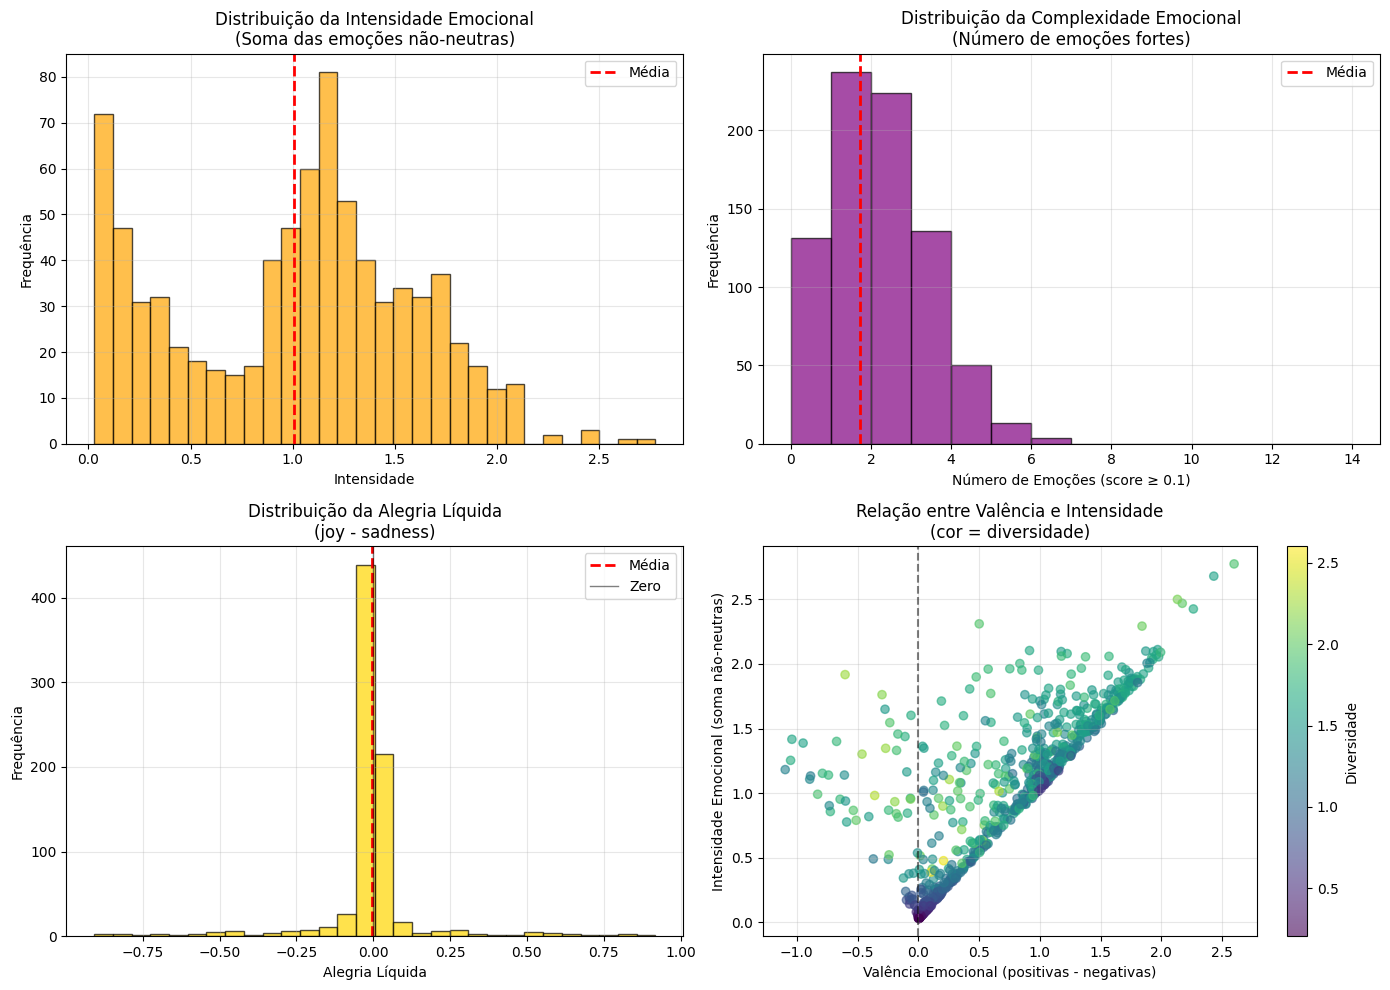

In [22]:
# Visualizar
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Intensidade emocional
axes[0, 0].hist(
    hinos_analise["intensidade_emocional"],
    bins=30,
    color="orange",
    alpha=0.7,
    edgecolor="black",
)
axes[0, 0].axvline(
    hinos_analise["intensidade_emocional"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Média",
)
axes[0, 0].set_title(
    "Distribuição da Intensidade Emocional\n(Soma das emoções não-neutras)"
)
axes[0, 0].set_xlabel("Intensidade")
axes[0, 0].set_ylabel("Frequência")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Número de emoções fortes
axes[0, 1].hist(
    hinos_analise["num_emocoes_fortes"],
    bins=range(0, 15),
    color="purple",
    alpha=0.7,
    edgecolor="black",
)
axes[0, 1].axvline(
    hinos_analise["num_emocoes_fortes"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Média",
)
axes[0, 1].set_title(
    "Distribuição da Complexidade Emocional\n(Número de emoções fortes)"
)
axes[0, 1].set_xlabel("Número de Emoções (score ≥ 0.1)")
axes[0, 1].set_ylabel("Frequência")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Alegria líquida
axes[1, 0].hist(
    hinos_analise["alegria_liquida"],
    bins=30,
    color="gold",
    alpha=0.7,
    edgecolor="black",
)
axes[1, 0].axvline(
    hinos_analise["alegria_liquida"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Média",
)
axes[1, 0].axvline(
    0, color="black", linestyle="-", linewidth=1, alpha=0.5, label="Zero"
)
axes[1, 0].set_title("Distribuição da Alegria Líquida\n(joy - sadness)")
axes[1, 0].set_xlabel("Alegria Líquida")
axes[1, 0].set_ylabel("Frequência")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Scatter: valencia vs intensidade
scatter = axes[1, 1].scatter(
    hinos_analise["valencia_emocional"],
    hinos_analise["intensidade_emocional"],
    c=hinos_analise["diversidade_emocional"],
    cmap="viridis",
    alpha=0.6,
)
axes[1, 1].axvline(0, color="black", linestyle="--", alpha=0.5)
axes[1, 1].set_xlabel("Valência Emocional (positivas - negativas)")
axes[1, 1].set_ylabel("Intensidade Emocional (soma não-neutras)")
axes[1, 1].set_title("Relação entre Valência e Intensidade\n(cor = diversidade)")
axes[1, 1].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 1], label="Diversidade")

plt.tight_layout()
plt.show()

In [23]:
# 2. RANKINGS E COMPARAÇÕES
print("\n\n2. Rankings - Top Hinos por Diferentes Métricas")
print("-" * 80)

# Top mais alegres
print("\n--- TOP 10 HINOS MAIS ALEGRES (maior alegria líquida) ---")
top_alegres = hinos_analise.nlargest(10, "alegria_liquida")
for i, row in enumerate(top_alegres.iterrows(), 1):
    idx, hino = row
    print(f"{i:2d}. {hino['nome'][:50]:<50s} | Alegria: {hino['alegria_liquida']:.3f}")

# Top mais tristes
print("\n--- TOP 10 HINOS MAIS TRISTES (menor alegria líquida) ---")
top_tristes = hinos_analise.nsmallest(10, "alegria_liquida")
for i, row in enumerate(top_tristes.iterrows(), 1):
    idx, hino = row
    print(f"{i:2d}. {hino['nome'][:50]:<50s} | Alegria: {hino['alegria_liquida']:.3f}")

# Top mais intensos
print("\n--- TOP 10 HINOS MAIS INTENSOS EMOCIONALMENTE ---")
top_intensos = hinos_analise.nlargest(10, "intensidade_emocional")
for i, row in enumerate(top_intensos.iterrows(), 1):
    idx, hino = row
    print(
        f"{i:2d}. {hino['nome'][:50]:<50s} | Intensidade: {hino['intensidade_emocional']:.3f}"
    )

# Top mais complexos emocionalmente
print("\n--- TOP 10 HINOS MAIS COMPLEXOS (múltiplas emoções) ---")
top_complexos = hinos_analise.nlargest(10, "num_emocoes_fortes")
for i, row in enumerate(top_complexos.iterrows(), 1):
    idx, hino = row
    print(
        f"{i:2d}. {hino['nome'][:50]:<50s} | Emoções fortes: {hino['num_emocoes_fortes']}"
    )

# Top mais positivos
print("\n--- TOP 10 HINOS MAIS POSITIVOS (maior valencia) ---")
top_positivos = hinos_analise.nlargest(10, "valencia_emocional")
for i, row in enumerate(top_positivos.iterrows(), 1):
    idx, hino = row
    print(
        f"{i:2d}. {hino['nome'][:50]:<50s} | Valência: {hino['valencia_emocional']:.3f}"
    )



2. Rankings - Top Hinos por Diferentes Métricas
--------------------------------------------------------------------------------

--- TOP 10 HINOS MAIS ALEGRES (maior alegria líquida) ---
 1. FELICIDADE É TER CRISTO AO MEU LADO                | Alegria: 0.918
 2. SÓ O PODER DE DEUS                                 | Alegria: 0.897
 3. QUE ALEGRIA                                        | Alegria: 0.820
 4. QUANDO A MÃO DE DEUS EM MIM VEIO TOCAR             | Alegria: 0.816
 5. ÀS VEZES, ALGUÉM ME PERGUNTA                       | Alegria: 0.800
 6. ELE É A MINHA ALEGRIA                              | Alegria: 0.774
 7. OS CÉUS PROCLAMAM                                  | Alegria: 0.700
 8. NÃO TEREI MAIS TRISTEZAS                           | Alegria: 0.647
 9. NESTA NOITE FELIZ                                  | Alegria: 0.624
10. NO DIA DA GRANDE GLÓRIA                            | Alegria: 0.617

--- TOP 10 HINOS MAIS TRISTES (menor alegria líquida) ---
 1. SE ANDA TRISTE O TEU VIVER 



3. Resumo Geral - Perfil Emocional da Coletânea
--------------------------------------------------------------------------------

Total de hinos analisados: 795

--- EMOÇÃO MÉDIA DA COLETÂNEA ---
Valência emocional: 0.734
  ➜ POSITIVA

Intensidade emocional: 1.007
Score líquido médio: 0.243
Diversidade emocional média: 1.272

--- DISTRIBUIÇÃO POR CATEGORIA ---
Positivas   : 495 hinos ( 62.3%)
Neutras     : 264 hinos ( 33.2%)
Negativas   :  36 hinos (  4.5%)

--- TOP 5 EMOÇÕES MAIS COMUNS ---
Love        : 321 hinos ( 40.4%)
Optimism    : 179 hinos ( 22.5%)
Admiration  :  53 hinos (  6.7%)
Desire      :  43 hinos (  5.4%)
Caring      :  36 hinos (  4.5%)


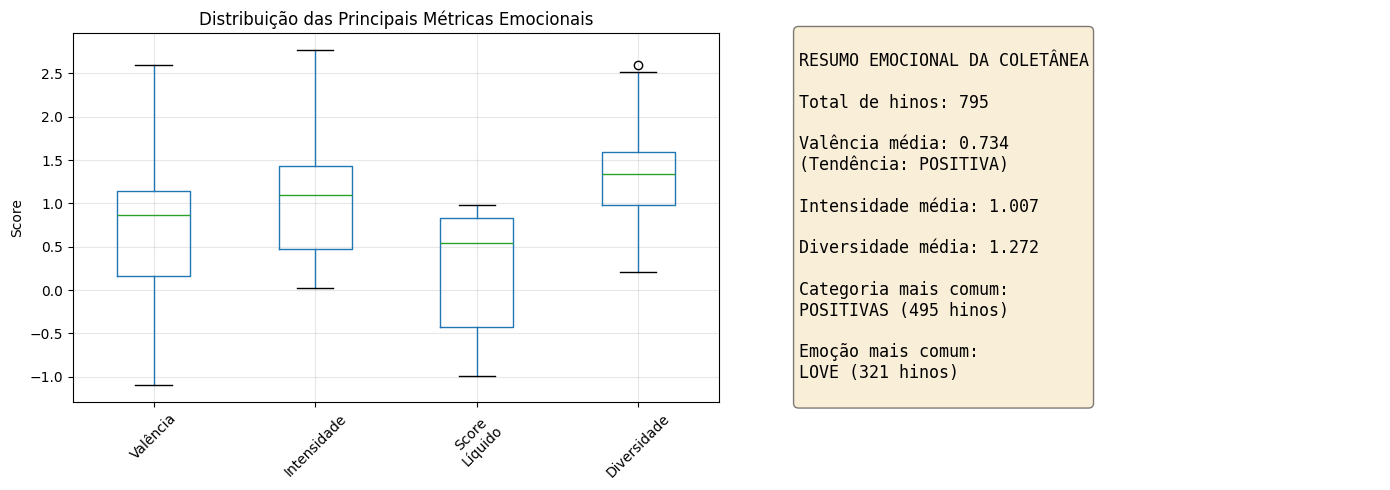


ANÁLISES COMPLETAS - TODAS AS MÉTRICAS AGREGADAS CALCULADAS!


In [24]:
# 3. RESUMO GERAL DA COLETÂNEA
print("\n\n3. Resumo Geral - Perfil Emocional da Coletânea")
print("-" * 80)

print(f"\nTotal de hinos analisados: {len(hinos_analise)}")
print(f"\n--- EMOÇÃO MÉDIA DA COLETÂNEA ---")
print(f"Valência emocional: {hinos_analise['valencia_emocional'].mean():.3f}")
print(
    f"  ➜ {'POSITIVA' if hinos_analise['valencia_emocional'].mean() > 0 else 'NEGATIVA'}"
)

print(f"\nIntensidade emocional: {hinos_analise['intensidade_emocional'].mean():.3f}")
print(f"Score líquido médio: {hinos_analise['score_liquido'].mean():.3f}")
print(
    f"Diversidade emocional média: {hinos_analise['diversidade_emocional'].mean():.3f}"
)

print(f"\n--- DISTRIBUIÇÃO POR CATEGORIA ---")
cat_dist = hinos_analise["categoria_dominante"].value_counts()
for cat, count in cat_dist.items():
    pct = (count / len(hinos_analise)) * 100
    print(f"{cat.capitalize():12s}: {count:3d} hinos ({pct:5.1f}%)")

print(f"\n--- TOP 5 EMOÇÕES MAIS COMUNS ---")
top_emocoes_geral = hinos_analise["emocao_dominante_sem_neutral"].value_counts().head(5)
for emocao, count in top_emocoes_geral.items():
    pct = (count / len(hinos_analise)) * 100
    print(f"{emocao.capitalize():12s}: {count:3d} hinos ({pct:5.1f}%)")

# Criar um resumo visual final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3. Box plot das métricas principais
metricas_principais = hinos_analise[
    [
        "valencia_emocional",
        "intensidade_emocional",
        "score_liquido",
        "diversidade_emocional",
    ]
]
metricas_principais.boxplot(ax=axes[0])
axes[0].set_title("Distribuição das Principais Métricas Emocionais")
axes[0].set_ylabel("Score")
axes[0].set_xticklabels(
    ["Valência", "Intensidade", "Score\nLíquido", "Diversidade"], rotation=45
)
axes[0].grid(alpha=0.3)

# 4. Resumo em texto
axes[1].axis("off")
resumo_texto = f"""
RESUMO EMOCIONAL DA COLETÂNEA

Total de hinos: {len(hinos_analise)}

Valência média: {hinos_analise['valencia_emocional'].mean():.3f}
(Tendência: {'POSITIVA' if hinos_analise['valencia_emocional'].mean() > 0 else 'NEGATIVA'})

Intensidade média: {hinos_analise['intensidade_emocional'].mean():.3f}

Diversidade média: {hinos_analise['diversidade_emocional'].mean():.3f}

Categoria mais comum:
{cat_dist.index[0].upper()} ({cat_dist.iloc[0]} hinos)

Emoção mais comum:
{top_emocoes_geral.index[0].upper()} ({top_emocoes_geral.iloc[0]} hinos)
"""
axes[1].text(
    0.1,
    0.5,
    resumo_texto,
    fontsize=12,
    verticalalignment="center",
    family="monospace",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("ANÁLISES COMPLETAS - TODAS AS MÉTRICAS AGREGADAS CALCULADAS!")
print("=" * 80)

# Heatmap por hino

Criando heatmap de emoções...


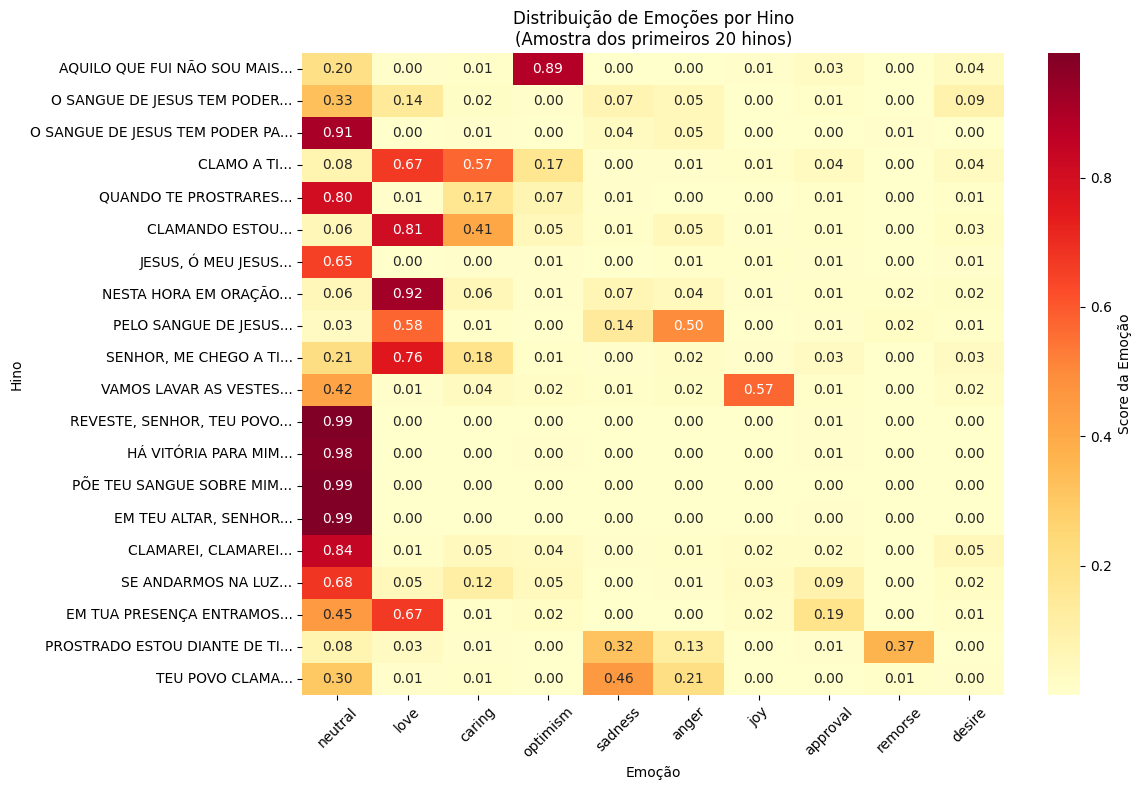

Heatmap criado com 20 hinos e 10 emoções principais.
Emoções visualizadas: ['neutral', 'love', 'caring', 'optimism', 'sadness', 'anger', 'joy', 'approval', 'remorse', 'desire']


In [25]:
# Visualização detalhada: Heatmap de emoções por hino
import seaborn as sns
import matplotlib.pyplot as plt

# Verificar se os dados foram processados
if "emocoes" not in hinos_analise.columns:
    print("Execute as células anteriores primeiro para processar as emoções!")
else:
    print("Criando heatmap de emoções...")

    # Expandir as emoções em colunas numéricas para uma amostra
    # (usar todos os hinos seria muito denso para visualizar)
    amostra_viz = hinos_analise.head(20).copy()  # Primeiros 20 hinos

    # Criar dataframe com as emoções expandidas
    emocoes_expandidas = []
    nomes_hinos = []

    for idx, row in amostra_viz.iterrows():
        if row["emocoes"]:
            emocoes_expandidas.append(row["emocoes"])
            nomes_hinos.append(row["nome"][:30] + "...")  # Truncar nomes longos

    if emocoes_expandidas:
        emo_df = pd.DataFrame(emocoes_expandidas, index=nomes_hinos)

        # Selecionar apenas as emoções mais comuns para visualização
        emocoes_principais = emo_df.mean().nlargest(10).index
        emo_df_filtrado = emo_df[emocoes_principais]

        plt.figure(figsize=(12, 8))
        sns.heatmap(
            emo_df_filtrado,
            annot=True,
            cmap="YlOrRd",
            fmt=".2f",
            cbar_kws={"label": "Score da Emoção"},
        )
        plt.title("Distribuição de Emoções por Hino\n(Amostra dos primeiros 20 hinos)")
        plt.xlabel("Emoção")
        plt.ylabel("Hino")
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

        print(
            f"Heatmap criado com {len(emo_df_filtrado)} hinos e {len(emocoes_principais)} emoções principais."
        )
        print(f"Emoções visualizadas: {list(emocoes_principais)}")
    else:
        print("Nenhuma emoção foi processada com sucesso. Verifique os dados.")

# Similaridade emocional entre hinos

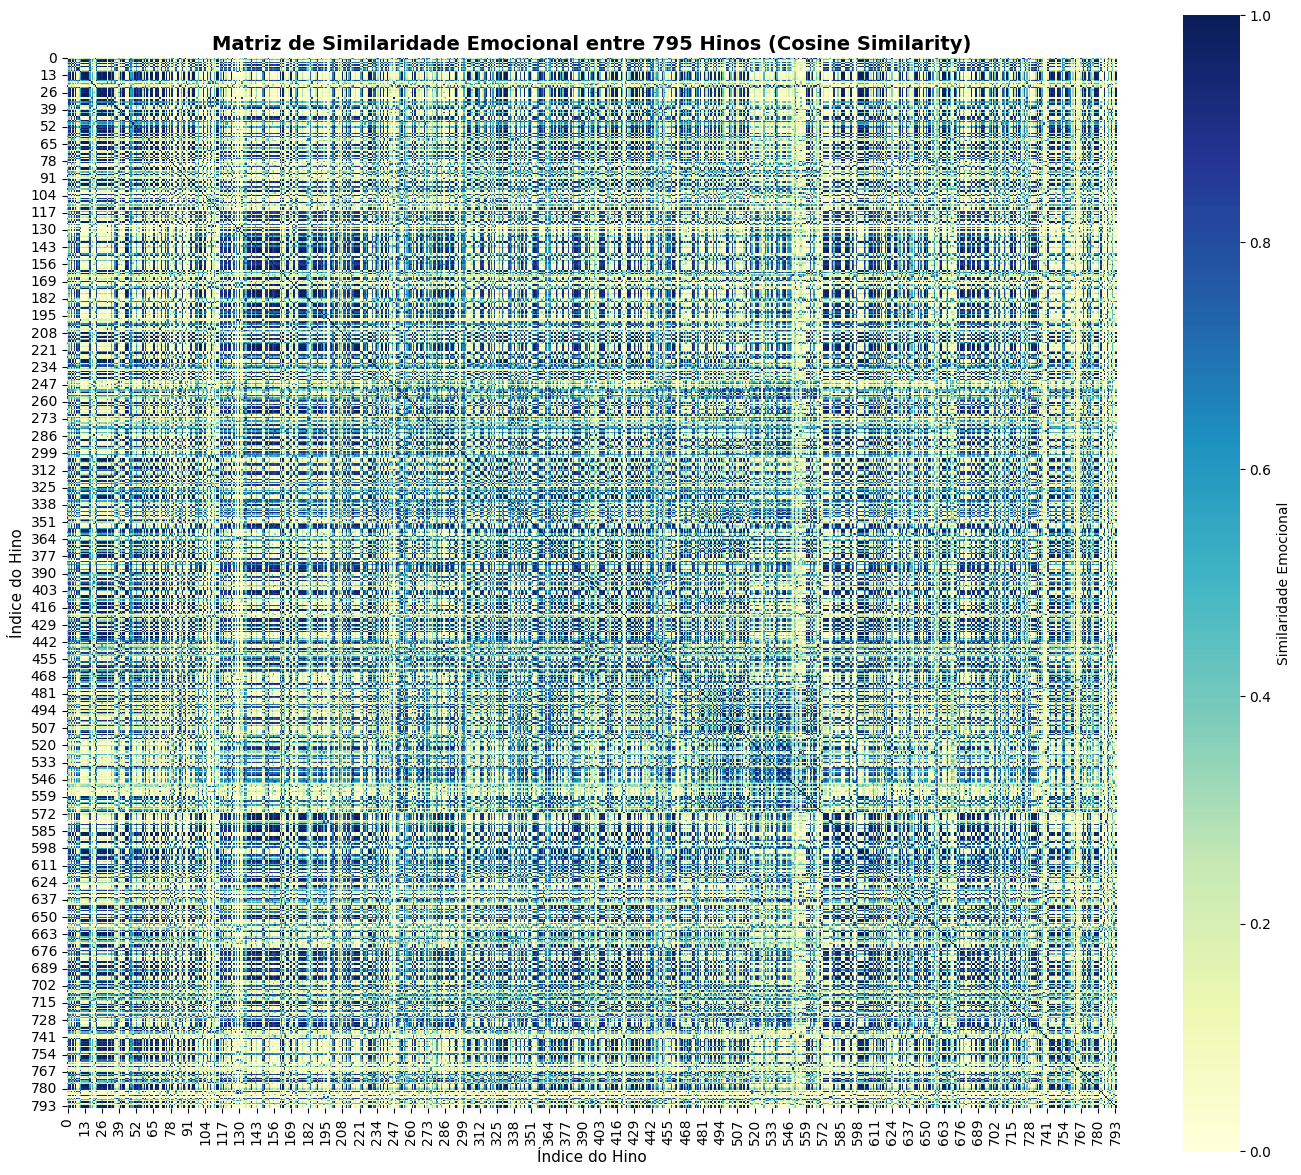

Matriz de features: (795, 28) (hinos x emoções)
Matriz de similaridade: (795, 795)
Similaridade média: 0.383
Similaridade mínima (excluindo diagonal): 0.002
Similaridade máxima (excluindo diagonal): 1.000


In [26]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Preparar matriz de features (cada linha é um hino, colunas são as emoções)
# Primeiro, identificar todas as emoções presentes
todas_emocoes = sorted(
    set(
        emocao
        for emocoes_dict in hinos_analise["emocoes"]
        for emocao in emocoes_dict.keys()
    )
)

# Criar matriz de features
matriz_features = np.array(
    [
        [hino["emocoes"].get(emocao, 0.0) for emocao in todas_emocoes]
        for _, hino in hinos_analise.iterrows()
    ]
)

# Calcular similaridade de cosseno (uma única chamada!)
matriz_similaridade = cosine_similarity(matriz_features)

# Criar DataFrame com os índices
matriz_sim_df = pd.DataFrame(
    matriz_similaridade, index=hinos_analise.index, columns=hinos_analise.index
)

# Visualizar
plt.figure(figsize=(14, 12))
sns.heatmap(
    matriz_sim_df,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"label": "Similaridade Emocional"},
)
plt.title(
    f"Matriz de Similaridade Emocional entre {len(hinos_analise)} Hinos (Cosine Similarity)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Índice do Hino", fontsize=11)
plt.ylabel("Índice do Hino", fontsize=11)
plt.tight_layout()
plt.show()

print(f"Matriz de features: {matriz_features.shape} (hinos x emoções)")
print(f"Matriz de similaridade: {matriz_sim_df.shape}")
print(
    f"Similaridade média: {matriz_sim_df.values[np.triu_indices_from(matriz_sim_df.values, k=1)].mean():.3f}"
)
print(
    f"Similaridade mínima (excluindo diagonal): {matriz_sim_df.values[np.triu_indices_from(matriz_sim_df.values, k=1)].min():.3f}"
)
print(
    f"Similaridade máxima (excluindo diagonal): {matriz_sim_df.values[np.triu_indices_from(matriz_sim_df.values, k=1)].max():.3f}"
)

---

**A seguir:** Salvamento dos resultados enriquecidos com análise de emoções para uso em outras etapas ou aplicações.

In [ ]:
hinos_analise.to_pickle("..\\assets\\hinos_analise_emotions.pkl")
matriz_sim_df.to_pickle("..\\assets\\similarity_matrix_emotions.pkl")

---

**Fim do notebook:** Finalização do processamento, com os dados prontos para exportação e uso em outras análises ou aplicações.